In [2]:
import re
import os 
import osmnx
import geopandas as gpd 
import pandas as pd
import matplotlib.pyplot as plt 
import folium
from pyhive import presto
from datetime import date
conn = presto.connect(
        host="bi-trino.serving.data.production.internal",
        port=80,
        username="abhishek.maity@rapido.bike"
    )

In [14]:
# AOI = {'city':'Indore','country':'India'}
AOI = 'Indore, India'

aoi_gdf = osmnx.geocode_to_gdf(AOI)
#plot area of interest
basemap = aoi_gdf.explore(color='lightblue')
basemap

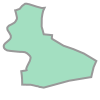

In [9]:
aoi_gdf.geometry.geometry.unary_union

In [5]:
import shapely, h3
from shapely.geometry.polygon import Polygon
from shapely.geometry.multipolygon import MultiPolygon
from shapely.geometry.point import Point
from shapely.geometry.linestring import LineString
from shapely.geometry import mapping

def geometry_to_hex(geometry,hex_resolution):
    hex_12_ids=set()
    
    try:
    
        if type(geometry) == MultiPolygon:
            geojson = [shapely.geometry.mapping(item) for item in geometry]
            hex_id = [h3.polyfill(item,hex_resolution) for item in geojson]
            for item in hex_id:
                hex_12_ids=hex_12_ids.union(item)

        elif type(geometry) == shapely.geometry.polygon.Polygon:
            geojson = shapely.geometry.mapping(geometry)
            hex_id = h3.polyfill(geojson,hex_resolution)
            hex_12_ids=hex_12_ids.union(hex_id)

        elif type(geometry) == Point:
            hex_id=h3.geo_to_h3(geometry.x, geometry.y, hex_resolution)
            hex_12_ids={hex_id}
        
        for item in hex_12_ids:
            hex_12_ids=hex_12_ids.union(h3.k_ring(item,1))
        return(hex_12_ids)
    
    except:
        pass


#geometry_to_hex(educational.reset_index()['geometry'][0],hex_resolution=12)
#geometry_to_hex(educational.reset_index()['geometry'][1478],hex_resolution=12)
#geometry_to_hex(educational.reset_index()['geometry'][1578],hex_resolution=12)
#geometry_to_hex(office['geometry'][186],hex_resolution=12)



In [7]:
educational = osmnx.geometries_from_polygon(polygon = aoi_gdf.geometry.geometry.unary_union,
                                      tags = {'buildings': ['school','university'],
                                              'amenity':['school','university','college'],
                                              'landuse':['education','school']})

#educational.explore(color = 'cyan',m= basemap)
educational=educational.reset_index()
educational['usecase']='educational'
educational.shape

/var/folders/ml/64ckxff94fz0_wh87gc4p2940000gn/T/ipykernel_63108/498332113.py:1: FutureWarning: The `geometries` module and `geometries_from_X` functions have been renamed the `features` module and `features_from_X` functions. Use these instead. The `geometries` module and function names are deprecated and will be removed in the v2.0.0 release.
  educational = osmnx.geometries_from_polygon(polygon = aoi_gdf.geometry.geometry.unary_union,


InsufficientResponseError: No data elements in server response. Check log and query location/tags.

In [8]:
place_of_worship = osmnx.geometries_from_polygon(polygon = aoi_gdf.geometry.geometry.unary_union,
                                      tags = {'building': ['temple','mosque','shrine','cathedral','chapel','synagogue','church'],
                                              'amenity':'place of worship'})

#place_of_worship.explore(color = 'green',m= basemap)

place_of_worship=place_of_worship.reset_index()
place_of_worship['usecase']='place_of_worship'
place_of_worship.shape

/var/folders/ml/64ckxff94fz0_wh87gc4p2940000gn/T/ipykernel_63108/241563652.py:1: FutureWarning: The `geometries` module and `geometries_from_X` functions have been renamed the `features` module and `features_from_X` functions. Use these instead. The `geometries` module and function names are deprecated and will be removed in the v2.0.0 release.
  place_of_worship = osmnx.geometries_from_polygon(polygon = aoi_gdf.geometry.geometry.unary_union,


InsufficientResponseError: No data elements in server response. Check log and query location/tags.

In [262]:
#osmnx.geometries_from_polygon(polygon = aoi_gdf.geometry.geometry.unary_union,
#                                      tags = {'landuse':'commercial'}).explore(color = 'green',m= basemap)

In [263]:
leisure = osmnx.geometries_from_polygon(polygon = aoi_gdf.geometry.geometry.unary_union,
                                      tags = {'leisure':True,
                                              'landuse':['beer_graden','recreation_ground','recreational','recreational_area'],
                                              'amenity':['arts_centre','casino','cinema','dive_centre','community_centre','brothel','internet_cafe','courthouse','cinema','sauna'],
                                              'building':'stadium'})

#leisure.explore(color = 'orange',m= basemap)
leisure=leisure.reset_index()
leisure['usecase']='leisure'
leisure.shape

(2116, 113)

In [264]:
transit_station = osmnx.geometries_from_polygon(polygon = aoi_gdf.geometry.geometry.unary_union,
                                      tags = {'railway':'station',
                                              'amenity':'bus_station',
                                              'highway':['bus_stand','platform'],
                                              'public_transport':'station',
                                             'landuse':'depot'})

#transit_station.explore(color = 'red',m= basemap)
transit_station=transit_station.reset_index()
transit_station['usecase']='transit_station'
transit_station.shape

(174, 69)

In [265]:
office = osmnx.geometries_from_polygon(polygon = aoi_gdf.geometry.geometry.unary_union,
                                      tags = {'building':['office','commercial']})

#office.explore(color = 'black',m= basemap)
office=office.reset_index()
office['usecase']='office'
office.shape

(475, 58)

In [266]:
health_and_personal = osmnx.geometries_from_polygon(polygon = aoi_gdf.geometry.geometry.unary_union,
                                      tags = {'amenity':['dentist','hospital','gym','clinic','nursing home'],
                                              'building':['dentist','hospital'],
                                              'landuse':'healthcare'})

#health_and_personal.explore(color = 'yellow',m= basemap)
health_and_personal=health_and_personal.reset_index()
health_and_personal['usecase']='health_and_personal'
health_and_personal.shape

(1252, 79)

In [267]:
food = osmnx.geometries_from_polygon(polygon = aoi_gdf.geometry.geometry.unary_union,
                                      tags = {'amenity':['bar','pub','resturant','fast_food','food_court','cafe','juice bar','kitchen','ice cream']})

#food.explore(color = 'brown',m= basemap)
food=food.reset_index()
food['usecase']='food'
food.shape

(671, 92)

In [268]:
residential = osmnx.geometries_from_polygon(polygon = aoi_gdf.geometry.geometry.unary_union,
                                      tags = {'landuse' : 'residential'})
# residential1 = osmnx.geometries_from_polygon(polygon = aoi_gdf.geometry.geometry.unary_union,
#                                       tags = {'building':['appartments','residential'],'highway':['residential']})

 
#residential.explore(color = 'grey',m= basemap)
residential=residential.reset_index()
residential['usecase']='residential'
residential.shape

(525, 47)

In [269]:
household_needs = osmnx.geometries_from_polygon(polygon = aoi_gdf.geometry.geometry.unary_union,
                                      tags = {'amenity':['car_rental','car_wash','fuel','bank'],
                                              'building':['civic','retail','kiosk']
                                              })

#household_needs.explore(color = 'olive',m= basemap)
household_needs=household_needs.reset_index()
household_needs['usecase']='household_needs'
household_needs.shape

(854, 120)

In [270]:
govt_amenity = osmnx.geometries_from_polygon(polygon = aoi_gdf.geometry.geometry.unary_union,
                                      tags = {'amenity':['fire_station','grave_yard','crematorium','fire hydrant','funeral hall','police','post office','post box','post depot'],
                                              'building':['police_station','post_office','passport_office']})

#govt_amenity.explore(color = 'magenta',m= basemap)
govt_amenity=govt_amenity.reset_index()
govt_amenity['usecase']='govt_amenity'
govt_amenity.shape

(116, 33)

In [271]:
import pandas as pd
bangalore_usecase = pd.concat([educational, place_of_worship, leisure, transit_station,office,health_and_personal, food, residential,household_needs,govt_amenity], axis=0)

In [272]:
from datetime import date
# bangalore_usecase.to_csv(AOI+str(date.today())+'_usecase.csv',index=False)
bangalore_usecase.shape

(7101, 264)

In [273]:
osm_df = bangalore_usecase[['osmid','geometry','usecase','name']]


osm_df['AOI'] = AOI
osm_df['run_date']=date.today()
osm_df.to_csv(AOI+str(date.today())+'_osm_usecase.csv',index=False,header=True)

/home/jovyan/.local/lib/python3.7/site-packages/geopandas/geodataframe.py:1351: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [274]:
#osm_df=pd.read_csv(AOI+'2023-08-29'+'_osm_usecase.csv')
osm_df.shape

(7101, 6)

In [275]:
bangalore_usecase['geometry_rev']=gpd.GeoSeries(bangalore_usecase['geometry']).map(lambda polygon: shapely.ops.transform(lambda x, y: (y, x), polygon))

bangalore_usecase['hex_12_id_set']=bangalore_usecase['geometry_rev'].apply(lambda x: geometry_to_hex(x,hex_resolution=12))

bangalore_usecase['hex_12_list']=bangalore_usecase['hex_12_id_set'].apply(lambda x: list(x))
bangalore_usecase=bangalore_usecase.explode('hex_12_list')
bangalore_usecase.head()

,element_type,osmid,amenity,name,geometry,created_by,name:te,addr:city,addr:district,addr:state,...,nohousenumber,fuel:autogas_lpg,fuel:air,brand:ar,fuel:super_petrol,contact:fax,cemetery,geometry_rev,hex_12_id_set,hex_12_list
0,node,316636515,university,University Library,POINT (78.52551 17.41717),NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (17.41717 78.52551),"{8c60b52cdc1c7ff, 8c60b52cdc1ebff, 8c60b52cdc1...",8c60b52cdc1c7ff
0,node,316636515,university,University Library,POINT (78.52551 17.41717),NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (17.41717 78.52551),"{8c60b52cdc1c7ff, 8c60b52cdc1ebff, 8c60b52cdc1...",8c60b52cdc1ebff
0,node,316636515,university,University Library,POINT (78.52551 17.41717),NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (17.41717 78.52551),"{8c60b52cdc1c7ff, 8c60b52cdc1ebff, 8c60b52cdc1...",8c60b52cdc1c5ff
0,node,316636515,university,University Library,POINT (78.52551 17.41717),NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (17.41717 78.52551),"{8c60b52cdc1c7ff, 8c60b52cdc1ebff, 8c60b52cdc1...",8c60b52cdc1e9ff
0,node,316636515,university,University Library,POINT (78.52551 17.41717),NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (17.41717 78.52551),"{8c60b52cdc1c7ff, 8c60b52cdc1ebff, 8c60b52cdc1...",8c60b52cdc18dff


In [276]:
bangalore_usecase['hex_12_list'].isna().sum()/bangalore_usecase['hex_12_list'].shape[0]

0.0008264055060808644

In [277]:
bangalore_usecase1 = bangalore_usecase[~bangalore_usecase['hex_12_list'].isna()]

bangalore_usecase1['hex_10_list'] = bangalore_usecase1['hex_12_list'].apply(lambda x: h3.h3_to_parent(x,10))

/home/jovyan/.local/lib/python3.7/site-packages/geopandas/geodataframe.py:1351: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [278]:
bangalore_usecase1.shape,bangalore_usecase.shape

((405035, 268), (405370, 267))

In [279]:
df=bangalore_usecase1[['osmid','geometry','usecase','hex_12_list','hex_10_list','name']]
#df.to_csv('Bangalore_usecase_osm.csv')

In [280]:
df[df['hex_10_list']=='8a61892eca4ffff'].groupby(['usecase']).name.count()

Series([], Name: name, dtype: int64)

In [281]:
df[df['hex_10_list']=='8a61892eca4ffff'].groupby(['osmid','usecase']).count()

,,geometry,hex_12_list,hex_10_list,name
osmid,usecase,,,,


In [282]:
df['hex_12_list'].nunique(),df['hex_10_list'].nunique(), df['osmid'].nunique(),df.shape

(368713, 13822, 6765, (405035, 6))

In [283]:
df.groupby(['hex_10_list'])['usecase'].nunique().reset_index()['usecase'].describe(percentiles=[0,.01,.05,.25,.5,.75,.9,.95,.99,1])

count    13822.000000
mean         1.292215
std          0.622792
min          1.000000
0%           1.000000
1%           1.000000
5%           1.000000
25%          1.000000
50%          1.000000
75%          1.000000
90%          2.000000
95%          3.000000
99%          4.000000
100%         6.000000
max          6.000000
Name: usecase, dtype: float64

In [284]:

# final_usecase_df = df.groupby(['hex_10_list','usecase'])['hex_12_list'].nunique().reset_index().sort_values('hex_12_list')
# final_usecase_df1 = final_usecase_df.drop_duplicates(subset=['hex_10_list'], keep='last')
# final_usecase_df1['hex_10_list'].value_counts()




final_usecase_df = df.groupby(['hex_10_list','usecase'])['name'].nunique().reset_index().sort_values('name')
final_usecase_df1 = final_usecase_df.drop_duplicates(subset=['hex_10_list'], keep='last')

final_usecase_df1=final_usecase_df1.rename(columns={'name':'hex_12_list'}) #bad practice

final_usecase_df1['hex_10_list'].value_counts()


8a60b5250097fff    1
8a60a259a977fff    1
8a60b52ce74ffff    1
8a60a2581787fff    1
8a60a25b6d8ffff    1
                  ..
8a60a258e987fff    1
8a60b520b5a7fff    1
8a60a25a8947fff    1
8a60b52e18f7fff    1
8a60a25a502ffff    1
Name: hex_10_list, Length: 13822, dtype: int64

In [286]:

AOI_geo= gpd.GeoSeries(aoi_gdf.geometry.geometry.unary_union).map(lambda polygon: shapely.ops.transform(lambda x, y: (y, x), polygon))

AOI_Bangalore = pd.DataFrame(geometry_to_hex(AOI_geo[0],hex_resolution=10),columns=['hex_10'])
AOI_Bangalore['AOI']=AOI
AOI_Bangalore['run_date']=date.today()
final_usecase = pd.merge(AOI_Bangalore,final_usecase_df1,left_on='hex_10',right_on='hex_10_list',how='left')

In [287]:
final_usecase.shape

(41735, 6)

In [288]:
final_usecase.drop(columns='hex_10_list').to_csv(AOI+str(date.today())+'_hex_12_10_usecase_osm_final_name.csv',index=False, header=True)

In [289]:
final_usecase.head()

,hex_10,AOI,run_date,hex_10_list,usecase,hex_12_list
0,8a60a25a4657fff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN
1,8a60a25a3117fff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN
2,8a60a24998f7fff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN
3,8a60a2584a9ffff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN
4,8a60a25b4c07fff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN


In [246]:
###end here#########

In [93]:
#final_usecase = pd.read_csv(AOI+'2023-08-29'+'_hex_12_10_usecase_osm_final.csv')

In [290]:
hex_dict=final_usecase[~final_usecase['usecase'].isnull()][['hex_10','usecase']].set_index('hex_10').T.to_dict('list')

In [291]:
def hex_neighbours(hex_dict,hex_id, ring):
    temp = {}
    hex_list = list(h3.k_ring(hex_id,ring))
    for item in hex_list:
        try:
            key = hex_dict[item][0]
            if key in temp.keys():
                temp[key] = temp[key]+1
            else:
                temp[key] = 1
        except:
            pass
    try:
        if 'transit_station' in temp.keys():
            return 'transit_station'
        elif 'office' in temp.keys():
            return 'office'
        elif 'educational' in temp.keys():
            return 'educational'
        elif 'place_of_worship' in temp.keys():
            return 'place_of_worship'
        else :
            return (max(zip(temp.values(), temp.keys()))[1])
    except :
        return 'Unknown'


In [292]:
final_usecase['1_ring_usecase']=final_usecase['hex_10'].apply(lambda x: hex_neighbours(hex_dict,x, 1))
final_usecase['2_ring_usecase']=final_usecase['hex_10'].apply(lambda x: hex_neighbours(hex_dict,x, 2))

In [293]:
final_usecase['usecase'].fillna('NA',inplace = True)
final_usecase.head()

,hex_10,AOI,run_date,hex_10_list,usecase,hex_12_list,1_ring_usecase,2_ring_usecase
0,8a60a25a4657fff,"Hyderabad, India",2023-09-01,NaN,NA,NaN,Unknown,transit_station
1,8a60a25a3117fff,"Hyderabad, India",2023-09-01,NaN,NA,NaN,Unknown,leisure
2,8a60a24998f7fff,"Hyderabad, India",2023-09-01,NaN,NA,NaN,Unknown,educational
3,8a60a2584a9ffff,"Hyderabad, India",2023-09-01,NaN,NA,NaN,Unknown,Unknown
4,8a60a25b4c07fff,"Hyderabad, India",2023-09-01,NaN,NA,NaN,leisure,educational


In [294]:
usecase = []
for x,y in zip(final_usecase['usecase'],final_usecase['1_ring_usecase']):
    if x == 'NA':
        usecase.append(y)
    else:
        usecase.append(x)
final_usecase['1_ring_usecase_'] = usecase

usecase = []
for x,y in zip(final_usecase['usecase'],final_usecase['2_ring_usecase']):
    if x == 'NA':
        usecase.append(y)
    else:
        usecase.append(x)
final_usecase['2_ring_usecase_'] = usecase

final_usecase.head()

,hex_10,AOI,run_date,hex_10_list,usecase,hex_12_list,1_ring_usecase,2_ring_usecase,1_ring_usecase_,2_ring_usecase_
0,8a60a25a4657fff,"Hyderabad, India",2023-09-01,NaN,NA,NaN,Unknown,transit_station,Unknown,transit_station
1,8a60a25a3117fff,"Hyderabad, India",2023-09-01,NaN,NA,NaN,Unknown,leisure,Unknown,leisure
2,8a60a24998f7fff,"Hyderabad, India",2023-09-01,NaN,NA,NaN,Unknown,educational,Unknown,educational
3,8a60a2584a9ffff,"Hyderabad, India",2023-09-01,NaN,NA,NaN,Unknown,Unknown,Unknown,Unknown
4,8a60a25b4c07fff,"Hyderabad, India",2023-09-01,NaN,NA,NaN,leisure,educational,leisure,educational


In [295]:
final_usecase.to_csv(AOI+str(date.today())+'_final_usecase_name.csv',index=False)

In [81]:
city='Bangalore'
start='20230424'
end='20230430'

fe_rr_query=f"""
with base as (
select customer_id, taxi_lifetime_last_ride_city, taxi_lifetime_stage, taxi_retention_segments, taxi_gc_tag,
taxi_time_of_day_preference, taxi_day_of_week_preference
from datasets.iallocator_customer_segments
where run_date = date_format(date_parse('{end}','%Y%m%d') + interval '1' day, '%Y-%m-%d')
and taxi_lifetime_last_ride_city = '{city}'
--and taxi_lifetime_last_ride_city in ('Delhi','New Delhi','Noida','Gurugram')
-- and taxi_lifetime_stage='COMMITTED'
),

base_fe_address_id as (
select *
from
(select 
eventprops_pickup_place_id as pickup_place_id, 
    eventprops_drop_place_id as drop_place_id, 
    pickup_address as pickup_address, 
    drop_address as drop_address,
    identity as customer_id,
    quarter_hour,
    yyyymmdd, 
    fare_estimate_id as fe_estimate_id, 
    current_city as city,
    city as city2,
    service_name as service, 
    ct_session_id as eventprops_ctsessionid,
    pickup_latitude as pickup_lat,
    pickup_longitude as pickup_lng,
    drop_location_latitude as drop_lat,
    drop_location_longitude as drop_lng,
    row_number() over (partition by cast(cast(ct_session_id as decimal) as varchar) || ' - ' || phone order by epoch desc) as fe_updated_seq,
    cast(cast(ct_session_id as decimal) as varchar) || ' - ' || phone AS unique_id
from canonical.clevertap_customer_fare_estimate
where yyyymmdd >= '{start}'
and yyyymmdd <= '{end}'

and current_city = '{city}'
--and current_city in ('Delhi','Gurugram','New Delhi','Noida')
and service_name in ('Auto','Link','Bike'))
where fe_updated_seq=1
),

base_rr_address_id as (
select *
from
(select pickup_address eventprops_pickaddress, drop_address as eventprops_dropaddress, user_id as customer_id, yyyymmdd, fare_estimate_id as rr_estimate_id, service_name  as eventprops_servicename, 
ct_session_id as eventprops_ctsessionid,
pickup_location_latitude as eventprops_picklat, pickup_location_longitude as eventprops_picklng,
row_number() over (partition by cast(cast(ct_session_id as decimal) as varchar) || ' - ' || phone order by epoch desc) as rr_updated_seq,
cast(cast(ct_session_id as decimal) as varchar) || ' - ' || phone AS unique_id
from canonical.clevertap_customer_request_rapido
where yyyymmdd >= '{start}'
and yyyymmdd <= '{end}'
and current_city = '{city}'

and service_name in ('Auto','Link','Bike'))
where rr_updated_seq=1
),
final as
(

select fe.*,rr.rr_estimate_id, rr.eventprops_servicename as rr_service, rr.unique_id as rrs
from
base_fe_address_id fe
left join
base_rr_address_id rr
on fe.unique_id = rr.unique_id
)

select
a.*,
b.*
from final a left join base b on a.customer_id = b.customer_id
"""
usecase_fe_rr_cust_new =pd.read_sql(fe_rr_query, conn)

In [82]:
usecase_fe_rr_cust_new.to_csv('usecase_fe_rr_cust_blr_weekly.csv',index=False)
# usecase_fe_rr_cust_new = pd.read_csv('usecase_fe_rr_cust_hyd_weekly.csv')
# usecase_fe_rr_cust_new.head()

In [ ]:
google_dump_query = f"""select *--lat, lon, description, place_id, predicted_tags, primary_location_type, h8index, h12index, city
from
datasets_internal.google_places_searchresults
where city = '{city}'"""

usecase_google_dump =pd.read_sql(google_dump_query, conn)

In [33]:
#usecase_google_dump.to_csv('usecase_google_dump_hyd.csv',index=False)
usecase_google_dump= pd.read_csv('usecase_google_dump_hyd.csv')
usecase_google_dump.head()

,lat,lon,description,place_id,reference,structured_text,predicted_tags,primary_location_type,h6index,h7index,h8index,h9index,h10index,h11index,h12index,city,epoch,yyyymmdd
0,17.373669,78.502180,"TULSI TRAVELS, MCH Colony, Old Malakpet, Hyder...",ChIJ6Z4oifaZyzsRV4BhW1IhQCg,ChIJ6Z4oifaZyzsRV4BhW1IhQCg,"{""main_text"":""TULSI TRAVELS"",""secondary_text"":...","['travel_agency', 'point_of_interest', 'establ...",travel_agency,8660a25b7ffffff,8760a25b4ffffff,8860a25b43fffff,8960a25b43bffff,8a60a25b4397fff,8b60a25b4393fff,8c60a25b43933ff,Hyderabad,1636030596144,20211104
1,17.458652,78.399814,"Road No 7, Sri Vivekananda Nagar, Borabanda, H...",EkhSb2FkIE5vIDcsIFNyaSBWaXZla2FuYW5kYSBOYWdhci...,EkhSb2FkIE5vIDcsIFNyaSBWaXZla2FuYW5kYSBOYWdhci...,"{""main_text"":""Road No 7"",""secondary_text"":""Sri...","['route', 'geocode']",route,8660a259fffffff,8760a259affffff,8860a259a3fffff,8960a259a3bffff,8a60a259a3affff,8b60a259a3a8fff,8c60a259a3a8dff,Hyderabad,1635995314517,20211104
2,17.463936,78.491818,"Sikh Road, Kiran Enclave, Bowenpally, Secunder...",EkRTaWtoIFJvYWQsIEtpcmFuIEVuY2xhdmUsIEJvd2VucG...,EkRTaWtoIFJvYWQsIEtpcmFuIEVuY2xhdmUsIEJvd2VucG...,"{""main_text"":""Sikh Road"",""secondary_text"":""Kir...","['route', 'geocode']",route,8660b1967ffffff,8760b1965ffffff,8860b19659fffff,8960b19658bffff,8a60b196589ffff,8b60b196588afff,8c60b196588a5ff,Hyderabad,1636021626151,20211104
3,17.456181,78.565587,"LIG-234, HB Colony Main Road, APHB Colony, Mou...",ChIJmTNIrIqbyzsRJfEjVw2CU1U,ChIJmTNIrIqbyzsRJfEjVw2CU1U,"{""main_text"":""LIG-234, HB Colony Main Road"",""s...","['street_address', 'geocode']",street_address,8660b52c7ffffff,8760b52c3ffffff,8860b52c31fffff,8960b52c30bffff,8a60b52c30affff,8b60b52c30a8fff,8c60b52c30a85ff,Hyderabad,1636024036145,20211104
4,17.467036,78.455690,"Sree Kranthi Digital Photo Studio, Raju Colony...",ChIJSTNQh4uQyzsRDAE2tm_9JaM,ChIJSTNQh4uQyzsRDAE2tm_9JaM,"{""main_text"":""Sree Kranthi Digital Photo Studi...","['point_of_interest', 'establishment']",point_of_interest,8660a2597ffffff,8760b196cffffff,8860b196c9fffff,8960b196c9bffff,8a60b196c9affff,8b60b196c9a8fff,8c60b196c9a83ff,Hyderabad,1636029609552,20211104


In [34]:
usecase_fe_rr_cust_new['drop_lat']= usecase_fe_rr_cust_new['drop_lat'].apply(lambda x: float(x))
usecase_fe_rr_cust_new['drop_lng']= usecase_fe_rr_cust_new['drop_lng'].apply(lambda x: float(x))
usecase_fe_rr_cust_new['pickup_lat']= usecase_fe_rr_cust_new['pickup_lat'].apply(lambda x: float(x))
usecase_fe_rr_cust_new['pickup_lng']= usecase_fe_rr_cust_new['pickup_lng'].apply(lambda x: float(x))

In [35]:
!pip install h3
import h3
usecase_fe_rr_cust_new['fe_hex_10_pickup']=usecase_fe_rr_cust_new.apply(lambda x: h3.geo_to_h3(x['pickup_lat'], x['pickup_lng'], 10), axis=1)


usecase_fe_rr_cust_new['fe_hex_10']=usecase_fe_rr_cust_new.apply(lambda x: h3.geo_to_h3(x['drop_lat'], x['drop_lng'], 10), axis=1)


In [36]:
pickup_usecase_merged = pd.merge(usecase_fe_rr_cust_new,usecase_google_dump,left_on='pickup_place_id',right_on='place_id',how='left')

drop_usecase_merged = pd.merge(usecase_fe_rr_cust_new,usecase_google_dump,left_on='drop_place_id',right_on='place_id',how='left')

In [51]:
#pickup_usecase_merged.to_csv(AOI+str(date.today())+'_pickup_usecase_merged.csv',index=False)
drop_usecase_merged.to_csv(AOI+str(date.today())+'_drop_usecase_merged.csv',index=False)

In [ ]:
#drop_usecase_merged=pd.read_csv(AOI+'2023-08-30'+'_drop_usecase_merged.csv')
#pickup_usecase_merged=pd.read_csv(AOI+'2023-08-29'+'_pickup_usecase_merged.csv')

In [37]:
pickup_usecase_merged.shape,drop_usecase_merged.shape

((3809451, 49), (3809451, 49))

In [38]:
import re
transit = ['airport','train ','train station','railway','rail','station','metro','subway','bus ','taxi']

office = ["tech","enterprises","techpark","developmental","industry","industrial","sez","ltd","private","pvt","office","tcs","work",
 "private limited","pvt","private","ltd","solutions","financial","hub","towers","tech ","office","tech ","deloitte",
 "SEZ","sez","industrial","industry","development","developmental","techpark","enterprises","ecospace","tower","accenture",
"ecospace","eco space"]            

educational = ['school','vidyalaya','primary school','secondary school','tution','book','tutors','knowledge','university','college']

food = ['bar','cafe','food','bakery','night club','restaurant','pub','eat ',
        'coffee','mess','pizza','tea','kfc','burger','biryani']

govt = ['city hall','courthouse','court','pwd','post office','government','govt','rto','rta','atm','petrol','police']


health = ['pharmacy','spa ','beauty','salon','dentist','doctor','gym','care','hair','health','hospital','medical',
         "care","cure","clinic","dental","medical","pharmaceutical","diagnostic","surgical","surgeon",'fitness']

hotels = ['lodging','hotels'] 

leisure = ['amusement','bowling','museum','park','garden','zoo','stadium','mall','campground','ground','tourist','theatre'
          'travel','multiplex']

residential = ['pg','hostel','apts','kuteer','apartment','flat','bhavan','paradise','township','residency','mansion','enclave','bungalow',
               "house","home","plot","flat","f no","p no","h no","home","enclave","residency","apartments","apartment","nilayam","nivas","society","community","gated","housing","hostel","pg","arcade","galli","estate","pg","quarters","township",'villa ',"door","door no","basti","d no","basthi","brindhavan"]


banks = ['finance','atm','bank','sbi']     


household_needs = ["shop","provision","store","electricals","market","shop no","bazaar","mkt","jewellers",
                   "mart","stores","store","bazar","bazar","ground","fashions","fashion","mandi ","bakery","spencers","d mart",
                   "super market","ratnadeep","studios","trade center","supermarket","super market",'car','repair','gas',
                   'parking','rental','bicycle']

place_of_worship = ['temple','hindu','church','mandir','dargah','mosque','synagogue']

def usecase_identifier(string):
    try :
        for x in transit:
            if re.search(x,string.lower()):
                return('airport|train|metro|bus|transit_station')
                break
            else:
                pass

        for x in office:
            if re.search(x,string.lower()):
                return('corporate office')
                break
            else:
                pass



        for x in educational:
            if re.search(x,string.lower()):
                return('educational')
                break
            else:
                pass



        for x in food:
            if re.search(x,string.lower()):
                return('food')
                break
            else:
                pass



        for x in govt:
            if re.search(x,string.lower()):
                return('govt_office')
                break
            else:
                pass



        for x in health:
            if re.search(x,string.lower()):
                return('health and personal care')
                break
            else:
                pass

        for x in hotels:
            if re.search(x,string.lower()):
                return('hotels')
                break
            else:
                pass




        for x in leisure:
            if re.search(x,string.lower()):
                return('leisure')
                break
            else:
                pass



        for x in residential:
            if re.search(x,string.lower()):
                return('Residential')
                break
            else:
                pass



        for x in banks:
            if re.search(x,string.lower()):
                return('Banking')
                break
            else:
                pass



        for x in household_needs:
            if re.search(x,string.lower()):
                return('household needs')
                break
            else:
                pass

        for x in place_of_worship:
            if re.search(x,string.lower()):
                return('place_of_worship')
                break
            else:
                pass



    
    except:
        return ('UNKNOWN')


    return ('UNKNOWN')


def google_tags_mapping(x):
    try:
        if x.lower() in ('airport','bus_station','transit_station','train_station','subway_station','taxi_stand'):
            return('airport|train|metro|bus|transit_station')
        elif x.lower() in ('finance','atm','bank','accounting'):
            return('Banking')
        elif x.lower() in ('establishment'):
            return('corporate office')
        elif x.lower() in ('school','university','secondary_school','primary_school'):
            return('educational')
        elif x.lower() in ('restaurant','food','bakery','grocery_or_supermarket','cafe','supermarket','meal_takeaway','meal_delivery','liquor_store','night_club'):
            return('food')
        elif x.lower() in ('local_government_office','lawyer','post_office','police','postal_code','embassy','political','courthouse','colloquial_area','administrative_area_level_2'):
            return('govt_office')
        elif x.lower() in ('health','beauty_salon','hospital','doctor','pharmacy','gym','hair_care','dentist','drugstore','physiotherapist','veterinary_care'):
            return('health and personal care')
        elif x.lower() in ('lodging'):
            return('hotels')
        elif x.lower() in ('general_contractor','real_estate_agency','hardware_store','laundry','storage','insurance_agency','pet_store','department_store','store','electrician',
                    'florist','moving_company','clothing_store','painter','cemetery','plumber','aquarium','intersection','locksmith','convenience_store','roofing_contractor',
                           'fire_station','funeral_home','car_repair','car_dealer','gas_station','parking','car_wash','car_rental','bicycle_store'):
            return('household needs')
        elif x.lower() in ('home_goods_store','electronics_store','shopping_mall','jewelry_store','furniture_store','park','shoe_store','bar','book_store','spa','natural_feature','library','movie_theater','art_gallery',
                    'museum','movie_rental','amusement_park','rv_park','bowling_alley','city_hall','zoo','town_square','stadium','campground','tourist_attraction','travel_agency'):
            return('leisure')
        elif x.lower() in ('hindu_temple','church','place_of_worship','mosque','synagogue'):
            return('place_of_worship')
        elif x.lower() in ('street_address','route','point_of_interest','premise','neighborhood','sublocality_level_2','geocode','locality','sublocality_level_3','sublocality_level_1','subpremise'):
            return('Residential')#High vs low confidence
        else:
            return('UNKNOWN')
    except:
        return('UNKNOWN')
    

def keyword_plus_google_tag(keyword,google_tag):
    if keyword == 'UNKNOWN':
        return(google_tag)
    else:
        return(keyword)

In [39]:
pickup_usecase_merged['pickup_address_tag']=pickup_usecase_merged['pickup_address'].apply(lambda x: usecase_identifier(x))
pickup_usecase_merged['pickup_address_tag'].value_counts()

UNKNOWN                                    2223653
Residential                                 568597
airport|train|metro|bus|transit_station     224937
corporate office                            211165
leisure                                     142950
household needs                             110693
educational                                  75339
health and personal care                     74052
food                                         60545
govt_office                                  53328
place_of_worship                             32419
Banking                                      31488
hotels                                         285
Name: pickup_address_tag, dtype: int64

In [40]:
drop_usecase_merged['drop_address_tag']=drop_usecase_merged['drop_address'].apply(lambda x: usecase_identifier(x))
drop_usecase_merged['drop_address_tag'].value_counts()

UNKNOWN                                    2828137
Residential                                 216236
airport|train|metro|bus|transit_station     207241
corporate office                            130992
leisure                                      80686
health and personal care                     80466
educational                                  79298
household needs                              67999
food                                         50628
place_of_worship                             27996
govt_office                                  27071
Banking                                      12116
hotels                                         585
Name: drop_address_tag, dtype: int64

In [41]:
pickup_usecase_merged['google_address_tag']=pickup_usecase_merged['primary_location_type'].apply(lambda x: google_tags_mapping(x))
pickup_usecase_merged['google_address_tag'].value_counts()

UNKNOWN                                    3332617
Residential                                 245771
food                                         46301
health and personal care                     38753
educational                                  30214
leisure                                      29478
airport|train|metro|bus|transit_station      27117
place_of_worship                             20778
household needs                              15556
hotels                                       10413
govt_office                                   8307
Banking                                       4125
corporate office                                21
Name: google_address_tag, dtype: int64

In [42]:
drop_usecase_merged['google_address_tag']=drop_usecase_merged['primary_location_type'].apply(lambda x: google_tags_mapping(x))
drop_usecase_merged['google_address_tag'].value_counts()

UNKNOWN                                    2242220
Residential                                 815609
leisure                                     125319
health and personal care                    120765
food                                        119630
educational                                 103832
airport|train|metro|bus|transit_station      87269
place_of_worship                             70982
household needs                              49279
govt_office                                  30768
hotels                                       28711
Banking                                      15018
corporate office                                49
Name: google_address_tag, dtype: int64

In [43]:
pickup_usecase_merged['final_pickup_tag']=pickup_usecase_merged.apply(lambda x: keyword_plus_google_tag(x['pickup_address_tag'],x['google_address_tag']), axis=1)
pickup_usecase_merged['final_pickup_tag'].value_counts()

UNKNOWN                                    2051047
Residential                                 674102
airport|train|metro|bus|transit_station     230623
corporate office                            211178
leisure                                     152444
household needs                             118615
educational                                  81865
health and personal care                     81129
food                                         75580
govt_office                                  55006
place_of_worship                             41996
Banking                                      32288
hotels                                        3578
Name: final_pickup_tag, dtype: int64

In [44]:
drop_usecase_merged['final_drop_tag'] = drop_usecase_merged.apply(lambda x: keyword_plus_google_tag(x['drop_address_tag'],x['google_address_tag']), axis=1)
drop_usecase_merged['final_drop_tag'].value_counts()

UNKNOWN                                    1694952
Residential                                 844895
airport|train|metro|bus|transit_station     264872
leisure                                     168095
health and personal care                    155816
educational                                 144074
food                                        133256
corporate office                            131031
household needs                             106732
place_of_worship                             77126
govt_office                                  46468
Banking                                      21547
hotels                                       20587
Name: final_drop_tag, dtype: int64

In [27]:
#drop_usecase_merged.to_csv(AOI+str(date.today())+'_drop_usecase_merged.csv')

In [ ]:
#pickup_usecase_merged.to_csv(AOI+str(date.today())+'_pickup_usecase_merged.csv')

In [45]:
drop_usecase_hex10=pd.pivot(drop_usecase_merged.groupby(['fe_hex_10','final_drop_tag']).count().reset_index(),index='fe_hex_10',columns='final_drop_tag',values='unique_id').fillna(0)

In [46]:
pickup_usecase_hex10=pd.pivot(pickup_usecase_merged.groupby(['fe_hex_10_pickup','final_pickup_tag']).count().reset_index(),index='fe_hex_10_pickup',columns='final_pickup_tag',values='unique_id').fillna(0)

In [47]:
def combine_pickup_drop(df_drop,df_pickup):
    cols = df_drop.reset_index().columns
    temp = pd.merge(df_drop.reset_index(),df_pickup.reset_index(), left_on='fe_hex_10',right_on='fe_hex_10_pickup', how='outer').fillna(0)
    
    for item in cols[1:]:
        temp[item] = temp[item+'_x']+ temp[item+'_y']
    temp['fe_hex_10'] = temp.apply(lambda x: x['fe_hex_10'] if x['fe_hex_10'] !=0 else x['fe_hex_10_pickup'],axis=1)
    return temp[cols]

In [48]:
final_usecase_df=combine_pickup_drop(drop_usecase_hex10,pickup_usecase_hex10)

In [228]:
#drop_usecase_hex10[drop_usecase_hex10['fe_hex_10']=='8a61892e3b6ffff']

In [49]:
final_usecase_df.to_csv(AOI+str(date.today())+'final_usecase_df.csv')

In [52]:
#final_usecase_df = pd.read_csv(AOI+str(date.today())+'final_usecase_df.csv').drop(columns='Unnamed: 0')
final_usecase_df.head()

,fe_hex_10,Banking,Residential,UNKNOWN,airport|train|metro|bus|transit_station,corporate office,educational,food,govt_office,health and personal care,hotels,household needs,leisure,place_of_worship
0,8a3c138c3777fff,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,8a3c138cb2effff,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,8a3c138cb9a7fff,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,8a3c138dc847fff,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,8a3c1640a0f7fff,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
def primary_hex_10_usecase(hex_df):

    hex_df['max_drop']=hex_df.drop('UNKNOWN',axis=1).max(axis=1)
    hex_df['Total_drop']=hex_df.sum(axis=1)-hex_df['max_drop']
    hex_df['max_drop_name']=hex_df.drop(columns=['fe_hex_10','UNKNOWN','max_drop','Total_drop'],axis=1).idxmax(axis=1,skipna=True)
    
    
    hex_df['max_drop%'] = hex_df['max_drop']/hex_df['Total_drop']
    hex_df['unknown_drop%'] = hex_df['UNKNOWN']/hex_df['Total_drop']
    hex_df['max_drop_name']=hex_df.apply(lambda x: 'UNKNOWN' if x['max_drop%']==0 else x['max_drop_name'],axis=1)
    
    return(hex_df)


In [54]:
final_primary_usecase_df = primary_hex_10_usecase(final_usecase_df)

In [55]:
final_primary_usecase_df['Total_drop'].quantile([0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.75,0.8,0.9,0.95,0.99,0.995,1.0])

0.050        1.00
0.100        1.00
0.200        2.00
0.300        4.00
0.400        8.00
0.500       19.00
0.600       39.00
0.700       76.00
0.750      103.00
0.800      139.00
0.900      274.00
0.950      451.00
0.990     1232.14
0.995     1771.07
1.000    68525.00
Name: Total_drop, dtype: float64

In [56]:
final_primary_usecase_df.sort_values('Total_drop',ascending = False).iloc[:20000,:]['max_drop%'].quantile([0.1,0.2,0.25,0.3,0.4,0.5,0.6,0.7,0.75,0.8,0.9,1.0])


0.10    0.099099
0.20    0.145299
0.25    0.165441
0.30    0.187286
0.40    0.229730
0.50    0.275087
0.60    0.326271
0.70    0.388494
0.75    0.424499
0.80    0.468233
0.90    0.583333
1.00    0.941176
Name: max_drop%, dtype: float64

In [57]:
final_primary_usecase_df['Keyword_search_confidence'] = final_primary_usecase_df['max_drop%'].apply(lambda x : '1. Low' if x <= 0.15 else '3. High' if x >= 0.3 else '2. Medium')


In [ ]:
# final_primary_usecase_df.columns = ['Banking', 'Residential', 'UNKNOWN',
#                                'airport|train|metro|bus|transit_station', 'corporate office',
#                                'educational', 'food', 'govt_office', 'health and personal care',
#                                'hotels', 'household needs', 'leisure', 'place_of_worship', 'max_drop',
#                                'Total_drop', 'max_drop_name', 'max_drop%',
#                                'unknown_drop%','Keyword_search_confidence']


# pickup_usecase_hex10.columns = ['Banking', 'Residential', 'UNKNOWN',
#                                'airport|train|metro|bus|transit_station', 'corporate office',
#                                'educational', 'food', 'govt_office', 'health and personal care',
#                                'hotels', 'household needs', 'leisure', 'place_of_worship', 'max_pickup',
#                                'Total_pickup', 'max_pickup_name', '2nd_max_pickup_name', 'max_pickup%',
#                                'unknown_pickup%','max_pickup%_bucket']

In [58]:
fe_count_hex_mapping = dict(zip(drop_usecase_merged['fe_hex_10'].value_counts().index,drop_usecase_merged['fe_hex_10'].value_counts()))
final_primary_usecase_df['drop_fe'] = final_primary_usecase_df['fe_hex_10'].map(fe_count_hex_mapping)

In [59]:
final_primary_usecase_df[final_primary_usecase_df['fe_hex_10']=='8a618920ba8ffff']

,fe_hex_10,Banking,Residential,UNKNOWN,airport|train|metro|bus|transit_station,corporate office,educational,food,govt_office,health and personal care,...,household needs,leisure,place_of_worship,max_drop,Total_drop,max_drop_name,max_drop%,unknown_drop%,Keyword_search_confidence,drop_fe


In [60]:
usecase_df = final_primary_usecase_df[['fe_hex_10','max_drop_name','Keyword_search_confidence','drop_fe']]


In [62]:
final_usecase=pd.read_csv('Hyderabad, India2023-09-01_final_usecase_name.csv')
merged_usecase = pd.merge(final_usecase,usecase_df,left_on ='hex_10',right_on = 'fe_hex_10',how = 'left')

merged_usecase.head()

,hex_10,AOI,run_date,hex_10_list,usecase,hex_12_list,1_ring_usecase,2_ring_usecase,1_ring_usecase_,2_ring_usecase_,fe_hex_10,max_drop_name,Keyword_search_confidence,drop_fe
0,8a60a25a4657fff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN,Unknown,transit_station,Unknown,transit_station,8a60a25a4657fff,place_of_worship,1. Low,26.0
1,8a60a25a3117fff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN,Unknown,leisure,Unknown,leisure,8a60a25a3117fff,leisure,3. High,NaN
2,8a60a24998f7fff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN,Unknown,educational,Unknown,educational,8a60a24998f7fff,Residential,3. High,1.0
3,8a60a2584a9ffff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,8a60a2584a9ffff,UNKNOWN,1. Low,4.0
4,8a60a25b4c07fff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN,leisure,educational,leisure,educational,8a60a25b4c07fff,Residential,1. Low,65.0


In [63]:
usecase = {'Banking':'household_needs','Residential':'residential','airport|train|metro|bus|transit_station':'transit_station',
          'corporate office':'office','govt_office':'govt_amenity','health and personal care':'health_and_personal',
          'hotels':'leisure','household needs':'household_needs','educational':'educational','food':'food',
          'place_of_worship' :'place_of_worship','leisure':'leisure'}

In [64]:
merged_usecase['keyword_google_usecase'] = merged_usecase['max_drop_name'].map(usecase)
merged_usecase['keyword_google_usecase'].fillna('Unknown',inplace=True)

merged_usecase['usecase'].fillna('Unknown').value_counts()

Unknown                28820
leisure                 3485
residential             3453
educational             2746
health_and_personal     1317
household_needs          676
office                   412
food                     410
transit_station          192
govt_amenity             170
place_of_worship          54
Name: usecase, dtype: int64

In [65]:
merged_usecase['keyword_google_usecase'].value_counts()

residential            17066
Unknown                10344
office                  2522
leisure                 2282
educational             2043
household_needs         1837
transit_station         1433
food                    1236
place_of_worship        1168
health_and_personal     1104
govt_amenity             700
Name: keyword_google_usecase, dtype: int64

In [66]:


merged_usecase['1_ring_disagrement'] = merged_usecase.apply(lambda x : 1 if x['keyword_google_usecase'] == x['1_ring_usecase_'] else 0,axis = 1)
merged_usecase['2_ring_disagrement'] = merged_usecase.apply(lambda x : 1 if x['keyword_google_usecase'] == x['2_ring_usecase_'] else 0,axis = 1)

merged_usecase['usecase']=merged_usecase['usecase'].apply(lambda x: 'Unknown' if x == 'NA' else x)

merged_usecase['osm_disagrement'] = merged_usecase.apply(lambda x : 1 if (x['usecase'] != x['keyword_google_usecase']) and ('Unknown' not in (x['usecase'],x['keyword_google_usecase'])) else 0,axis = 1)



In [67]:
merged_usecase.head()

,hex_10,AOI,run_date,hex_10_list,usecase,hex_12_list,1_ring_usecase,2_ring_usecase,1_ring_usecase_,2_ring_usecase_,fe_hex_10,max_drop_name,Keyword_search_confidence,drop_fe,keyword_google_usecase,1_ring_disagrement,2_ring_disagrement,osm_disagrement
0,8a60a25a4657fff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN,Unknown,transit_station,Unknown,transit_station,8a60a25a4657fff,place_of_worship,1. Low,26.0,place_of_worship,0,0,1
1,8a60a25a3117fff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN,Unknown,leisure,Unknown,leisure,8a60a25a3117fff,leisure,3. High,NaN,leisure,0,1,1
2,8a60a24998f7fff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN,Unknown,educational,Unknown,educational,8a60a24998f7fff,Residential,3. High,1.0,residential,0,0,1
3,8a60a2584a9ffff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,8a60a2584a9ffff,UNKNOWN,1. Low,4.0,Unknown,1,1,0
4,8a60a25b4c07fff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN,leisure,educational,leisure,educational,8a60a25b4c07fff,Residential,1. Low,65.0,residential,0,0,1


In [68]:
def usecase_decider(keyword_usecase,one_ring_usecase,two_ring_usecase,confidence):
    if keyword_usecase != 'Unknown':
        if two_ring_usecase != 'transit_station': 
            if keyword_usecase == one_ring_usecase:
                return keyword_usecase
            elif keyword_usecase == two_ring_usecase:
                return(keyword_usecase)
            elif confidence in ('2. Medium','3. High'):
                return(keyword_usecase)
            elif one_ring_usecase != 'Unknown':
                return(one_ring_usecase)
            elif two_ring_usecase != 'Unknown':
                return(two_ring_usecase)
            else:
                return(keyword_usecase)
        else :
            return 'transit_station'   
    else:
        if one_ring_usecase != 'Unknown':
            return(one_ring_usecase)
        else:
            return(two_ring_usecase)  
        

def usecase_decider_accurate(keyword_usecase,usecase,one_ring_usecase,confidence,demand):
    if keyword_usecase != 'Unknown':
        if usecase == keyword_usecase:
            return(keyword_usecase)
        elif 'transit_station' in (usecase,keyword_usecase):
            return('transit_station')
        elif 'office' in (usecase,keyword_usecase):
            return('office')
        
        elif confidence in ('3. High','2. Medium') and demand > 25:
            return(keyword_usecase)
        elif usecase != 'Unknown':
            return(usecase)
        elif confidence in (['3. High','2. Medium']) :
            return(keyword_usecase)
        else :
            return(one_ring_usecase)   
    else:
        if usecase != 'Unknown':
            return(usecase)
        else:
            return(one_ring_usecase)
        
        

            

In [69]:
merged_usecase['merged_usecase_coverage'] = merged_usecase.apply(lambda x : usecase_decider(x['keyword_google_usecase'],x['1_ring_usecase_'],
                                                x['2_ring_usecase_'],x['Keyword_search_confidence']),axis = 1)

merged_usecase['merged_usecase_accuracy'] = merged_usecase.apply(lambda x : usecase_decider_accurate(x['keyword_google_usecase'],x['usecase'],
                                                x['1_ring_usecase_'],x['Keyword_search_confidence'],x['drop_fe']),axis = 1)

merged_usecase['hex_8'] = merged_usecase['hex_10'].apply(lambda x: h3.h3_to_parent(x,8))

merged_usecase.head()

,hex_10,AOI,run_date,hex_10_list,usecase,hex_12_list,1_ring_usecase,2_ring_usecase,1_ring_usecase_,2_ring_usecase_,...,max_drop_name,Keyword_search_confidence,drop_fe,keyword_google_usecase,1_ring_disagrement,2_ring_disagrement,osm_disagrement,merged_usecase_coverage,merged_usecase_accuracy,hex_8
0,8a60a25a4657fff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN,Unknown,transit_station,Unknown,transit_station,...,place_of_worship,1. Low,26.0,place_of_worship,0,0,1,transit_station,NaN,8860a25a47fffff
1,8a60a25a3117fff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN,Unknown,leisure,Unknown,leisure,...,leisure,3. High,NaN,leisure,0,1,1,leisure,NaN,8860a25a31fffff
2,8a60a24998f7fff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN,Unknown,educational,Unknown,educational,...,Residential,3. High,1.0,residential,0,0,1,residential,NaN,8860a24999fffff
3,8a60a2584a9ffff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,...,UNKNOWN,1. Low,4.0,Unknown,1,1,0,Unknown,NaN,8860a2584bfffff
4,8a60a25b4c07fff,"Hyderabad, India",2023-09-01,NaN,NaN,NaN,leisure,educational,leisure,educational,...,Residential,1. Low,65.0,residential,0,0,1,leisure,NaN,8860a25b4dfffff


In [73]:
keppler_file = merged_usecase[['hex_10','drop_fe','usecase','keyword_google_usecase','merged_usecase_accuracy','merged_usecase_coverage',
                               'Keyword_search_confidence','1_ring_usecase_','2_ring_usecase','1_ring_disagrement','2_ring_disagrement','osm_disagrement','hex_8']]


city='Hyderabad'

from pyhive import presto 
conn = presto.connect(
        host="bi-trino.serving.data.production.internal",
        port=80,
        username="abhishek.maity@rapido.bike"
    )

query=f""" select hex_id as hex_8,cluster
from datasets.city_cluster_hex
where resolution = 8
and city = '{city}' """

# conn = get_presto_connection()
cluster = pd.read_sql(query, conn)
# cluster = pd.read_csv('Bangalore-hex-cluster.csv')

keppler_file = pd.merge(keppler_file,cluster, on='hex_8',how='left')


In [78]:
uplod_file = merged_usecase[['hex_10','AOI','run_date','usecase','1_ring_usecase_','2_ring_usecase_','keyword_google_usecase',
                             'merged_usecase_coverage','merged_usecase_accuracy','Keyword_search_confidence','hex_8']]
uplod_file['merged_usecase_accuracy']=uplod_file['merged_usecase_accuracy'].fillna('Unknown')

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [79]:
uplod_file.to_csv(AOI+str(date.today())+'usecase_data_upload_name1.csv', index=False,header=False)


In [76]:
keppler_file.to_csv(AOI+str(date.today())+'usecase_data_keppler_name1.csv', index=False)


In [77]:
uplod_file.shape

(41735, 11)

In [167]:
keppler_file.head()

,hex_10,drop_fe,usecase,keyword_google_usecase,merged_usecase_accuracy,merged_usecase_coverage,Keyword_search_confidence,1_ring_usecase_,2_ring_usecase,1_ring_disagrement,2_ring_disagrement,osm_disagrement,hex_8,cluster
0,8a60145846f7fff,26.0,Unknown,office,office,office,2. Medium,Unknown,leisure,0,0,0,8860145847fffff,Basaveshwar Nagar
1,8a61892cea07fff,232.0,office,office,office,office,3. High,office,office,1,1,0,8861892cebfffff,Nagavara
2,8a60145b2d17fff,NaN,Unknown,Unknown,Unknown,leisure,NaN,Unknown,leisure,1,0,0,8860145b2dfffff,R T Nagar
3,8a60145110b7fff,NaN,residential,Unknown,residential,residential,NaN,residential,residential,0,0,0,8860145111fffff,Hemmigepura
4,8a6014581c57fff,NaN,Unknown,Unknown,Unknown,Unknown,NaN,Unknown,Unknown,1,1,0,886014581dfffff,Nagarbhavi


In [254]:
pre_ind = pd.read_csv('Bangalore, India2023-09-01usecase_data_upload_name.csv')
ind = pd.read_csv('Bangalore, India2023-09-01usecase_data_upload_name1.csv')


pre_ind.columns = ['hex_10','AOI','run_date','usecase','1_ring_usecase_','2_ring_usecase_','keyword_google_usecase',
                             'merged_usecase_coverage','merged_usecase_accuracy','max_drop%_bucket','hex_8']


ind.columns = ['hex_10','AOI','run_date','usecase','1_ring_usecase_','2_ring_usecase_','keyword_google_usecase',
                             'merged_usecase_coverage','merged_usecase_accuracy','max_drop%_bucket','hex_8']


merge = pd.merge(pre_ind,ind,on = 'hex_10',how = 'inner')

office_hex = merge[(merge['merged_usecase_accuracy_x'] == 'office') & (merge['merged_usecase_accuracy_y'] != 'office')]['hex_10']



In [255]:
pd.crosstab(merge['merged_usecase_accuracy_x'],merge['merged_usecase_accuracy_y'])

merged_usecase_accuracy_y,Unknown,educational,food,govt_amenity,health_and_personal,household_needs,leisure,office,place_of_worship,residential,transit_station
merged_usecase_accuracy_x,,,,,,,,,,,
Unknown,8386,0,0,0,0,0,0,0,0,0,0
educational,0,5368,0,0,0,0,0,0,0,0,0
food,0,0,1187,0,0,0,0,0,0,0,0
govt_amenity,0,0,0,383,0,0,0,0,0,0,0
health_and_personal,0,0,0,0,2063,0,0,0,0,0,0
household_needs,0,0,0,0,0,1868,0,0,0,0,0
leisure,0,0,0,0,0,0,5499,0,0,0,0
office,0,0,0,0,0,0,0,3899,0,0,0
place_of_worship,0,0,0,0,0,0,0,0,861,0,0


In [188]:
usecase_fe_rr_cust_new[usecase_fe_rr_cust_new['fe_hex_10'].isin(office_hex)]['fe_hex_10'].value_counts()[:10]



8a618925d947fff    6747
8a60145b56d7fff    4470
8a618920baaffff    3547
8a618925a697fff    2382
8a618925c6e7fff    2187
8a618925d6c7fff    1731
8a618925e947fff    1715
8a61892ee917fff    1619
8a618920ba8ffff    1421
8a6189254227fff    1304
Name: fe_hex_10, dtype: int64

In [202]:
merge[merge['hex_10'] == '8a6189254227fff']

,hex_10,AOI_x,run_date_x,usecase_x,1_ring_usecase__x,2_ring_usecase__x,keyword_google_usecase_x,merged_usecase_coverage_x,merged_usecase_accuracy_x,max_drop%_bucket_x,...,AOI_y,run_date_y,usecase_y,1_ring_usecase__y,2_ring_usecase__y,keyword_google_usecase_y,merged_usecase_coverage_y,merged_usecase_accuracy_y,max_drop%_bucket_y,hex_8_y
39923,8a6189254227fff,"Bangalore, India",2023-09-01,office,office,office,residential,residential,office,2. Medium,...,"Bangalore, India",2023-09-01,residential,residential,residential,residential,residential,residential,2. Medium,8861892543fffff


In [209]:
usecase_fe_rr_cust_new[usecase_fe_rr_cust_new['fe_hex_10'] == '8a618920ba8ffff']['drop_address'].value_counts()

Innovative Multiplex Skywalk, Marathahalli - Sarjapur Outer Ring Road, Chandra Layout, Marathahalli, Bengaluru, Karnataka, India                                                         233
Innovative Multiplex, near Innovative Multiplex, Marathahalli Village, Marathahalli, Bengaluru, Karnataka, India                                                                         119
Barkaas, next to Innovative multiplex, Marathahalli Village, Marathahalli, Bengaluru, Karnataka, India                                                                                    25
Sidewalk Bar & Kitchen, Marathahalli - Sarjapur Outer Ring Road, behind bata showroom, Marathahalli Village, Marathahalli, Bengaluru, Karnataka, India                                    23
Sidewalk The Garden Bar, Marathahalli Village, Marathahalli, Bengaluru, Karnataka, India                                                                                                  23
Awfis Soul Space Paradigm, Hobli, Marathahalli Village,

In [ ]:
###### Hex tagging End ######

# Hex deep dive for Office

In [78]:
usecase_fe_rr_cust_new['final_usecase'] = usecase_fe_rr_cust_new['fe_hex_10'].map(dict(zip(keppler_file['hex_10'],keppler_file['merged_usecase_accuracy'])))
usecase_fe_rr_cust_new['final_cluster'] = usecase_fe_rr_cust_new['fe_hex_10'].map(dict(zip(keppler_file['hex_10'],keppler_file['cluster'])))
usecase_fe_rr_cust_new['confidence'] = usecase_fe_rr_cust_new['fe_hex_10'].map(dict(zip(keppler_file['hex_10'],keppler_file['max_drop%_bucket'])))



usecase_fe_rr_cust_new['final_usecase_p'] = usecase_fe_rr_cust_new['fe_hex_10_pickup'].map(dict(zip(keppler_file_p['hex_10'],keppler_file_p['merged_usecase_accuracy'])))
usecase_fe_rr_cust_new['final_cluster_p'] = usecase_fe_rr_cust_new['fe_hex_10_pickup'].map(dict(zip(keppler_file_p['hex_10'],keppler_file_p['cluster'])))
usecase_fe_rr_cust_new['confidence_p'] = usecase_fe_rr_cust_new['fe_hex_10_pickup'].map(dict(zip(keppler_file_p['hex_10'],keppler_file_p['max_pickup%_bucket'])))

# 
usecase_fe_rr_cust_new.head()

,pickup_place_id,drop_place_id,pickup_address,drop_address,customer_id,quarter_hour,yyyymmdd,fe_estimate_id,city,service,...,fe_hex_12_pickup,fe_hex_8,fe_hex_10,fe_hex_12,final_usecase,final_cluster,confidence,final_usecase_p,final_cluster_p,confidence_p
0,NaN,NaN,"37, 3rd Main Rd, Lakshmi Sagar Layout, RHB Col...","1774, Uday Nagar Main Rd, Bangalore Corporatio...",5fa64b7932de97dcd78c201a,745,20230428,644b2f8161ec666277a01d96,Bangalore,Link,...,8c61892e01aabff,8861892e3bfffff,8a61892e3b77fff,8c61892e3b707ff,office,K R Puram,2. 31-69,office,Mahadevpura RHB Colony,1. <=30
1,NaN,NaN,NaN,"Banashankari Metro Station., Kanakapura Road, ...",61e5410450f34b08668daaa4,500,20230428,644b07af82053034b94e9052,Bangalore,Bike,...,8c6014514948bff,88618924a7fffff,8a618924a777fff,8c618924a7769ff,transit_station,Banashankri,3. >=70,household_needs,Mallasandra,1. <=30
2,NaN,NaN,"33, 5th Main Rd, Near I.V Sanctum Hotel, Gandh...","Attibele, Karnataka, India",644a80a4ccecd03083a32ecf,0,20230428,644ac13745839c18c8c4cdb8,Bangalore,Link,...,8c60145b5595bff,8861893445fffff,8a61893444b7fff,8c61893444b05ff,NaN,NaN,NaN,household_needs,Majestic,1. <=30
3,ChIJLUU0LmIVrjsRT1S_7-egkyQ,ChIJeRJcpvcRrjsRHhY5F8GFHNo,"Gromart Fish and chicken, 1st Cross Road, Zuzu...","KR Puram Railway Station, 16, Vijinapura, Door...",6357c7ef3fdb4c34cef8d24c,330,20230428,644af17c940c3aa464347a40,Bangalore,Link,...,8c618925c05a5ff,8861892e39fffff,8a61892e3857fff,8c61892e38505ff,transit_station,Mahadevpura,3. >=70,residential,Madiwala,2. 31-69
4,NaN,ChIJU5CAQQUUrjsRFR9W0npBmHU,"84, 6th Cross Rd, Airports Authority of India ...","Diamond District, HAL Old Airport Road, ISRO C...",5844c89f2989ca036aad0209,1430,20230425,644799f5c0a7a80e91e7c263,Bangalore,Link,...,8c61892ed1133ff,8861892531fffff,8a61892530d7fff,8c61892530d67ff,transit_station,Domlur Embassy Business Park,3. >=70,health_and_personal,Cambridge Layout Ulsoor,1. <=30


In [79]:
usecase_fe_rr_cust_new['service'].unique()

array(['Link', 'Bike', 'Auto'], dtype=object)

In [80]:
usecase_fe_rr_cust_new['TOD_bucket'] =  usecase_fe_rr_cust_new['quarter_hour'].apply(lambda x : 'morning' if (x >= 800 and x <= 1200) else 'afternoon' if x>1200 and x<= 1600 else 'evening' if x > 1600 and x<= 2200 else 'night')


usecase_fe_rr_cust_new['date'] = pd.to_datetime(usecase_fe_rr_cust_new['yyyymmdd'],format='%Y%m%d')
usecase_fe_rr_cust_new['dow'] = usecase_fe_rr_cust_new['date'].apply(lambda x : x.dayofweek)
# pickup_usecase_merged['date'] = pd.to_datetime(pickup_usecase_merged['yyyymmdd_x'],format='%Y%m%d')
# pickup_usecase_merged['dow'] = pickup_usecase_merged['date'].apply(lambda x : x.dayofweek)

usecase_fe_rr_cust_new['day_type']= usecase_fe_rr_cust_new['dow'].apply(lambda x : 'weekend' if x >4 else 'weekday')
# pickup_usecase_merged['day_type']= pickup_usecase_merged['dow'].apply(lambda x : 'weekend' if x >4 else 'weekday')

usecase_fe_rr_cust_new.head()

,pickup_place_id,drop_place_id,pickup_address,drop_address,customer_id,quarter_hour,yyyymmdd,fe_estimate_id,city,service,...,final_usecase,final_cluster,confidence,final_usecase_p,final_cluster_p,confidence_p,TOD_bucket,date,dow,day_type
0,NaN,NaN,"37, 3rd Main Rd, Lakshmi Sagar Layout, RHB Col...","1774, Uday Nagar Main Rd, Bangalore Corporatio...",5fa64b7932de97dcd78c201a,745,20230428,644b2f8161ec666277a01d96,Bangalore,Link,...,office,K R Puram,2. 31-69,office,Mahadevpura RHB Colony,1. <=30,night,2023-04-28,4,weekday
1,NaN,NaN,NaN,"Banashankari Metro Station., Kanakapura Road, ...",61e5410450f34b08668daaa4,500,20230428,644b07af82053034b94e9052,Bangalore,Bike,...,transit_station,Banashankri,3. >=70,household_needs,Mallasandra,1. <=30,night,2023-04-28,4,weekday
2,NaN,NaN,"33, 5th Main Rd, Near I.V Sanctum Hotel, Gandh...","Attibele, Karnataka, India",644a80a4ccecd03083a32ecf,0,20230428,644ac13745839c18c8c4cdb8,Bangalore,Link,...,NaN,NaN,NaN,household_needs,Majestic,1. <=30,night,2023-04-28,4,weekday
3,ChIJLUU0LmIVrjsRT1S_7-egkyQ,ChIJeRJcpvcRrjsRHhY5F8GFHNo,"Gromart Fish and chicken, 1st Cross Road, Zuzu...","KR Puram Railway Station, 16, Vijinapura, Door...",6357c7ef3fdb4c34cef8d24c,330,20230428,644af17c940c3aa464347a40,Bangalore,Link,...,transit_station,Mahadevpura,3. >=70,residential,Madiwala,2. 31-69,night,2023-04-28,4,weekday
4,NaN,ChIJU5CAQQUUrjsRFR9W0npBmHU,"84, 6th Cross Rd, Airports Authority of India ...","Diamond District, HAL Old Airport Road, ISRO C...",5844c89f2989ca036aad0209,1430,20230425,644799f5c0a7a80e91e7c263,Bangalore,Link,...,transit_station,Domlur Embassy Business Park,3. >=70,health_and_personal,Cambridge Layout Ulsoor,1. <=30,afternoon,2023-04-25,1,weekday


In [230]:
rmz_ecospace = usecase_fe_rr_cust_new[usecase_fe_rr_cust_new['final_cluster'] == 'RMZ Ecospace']

rmz_ecospace_p = usecase_fe_rr_cust_new[usecase_fe_rr_cust_new['final_cluster_p'] == 'RMZ Ecospace']

In [231]:
rmz_ecospace_p['fe_hex_10'].value_counts()

8a61892549b7fff    105
8a6189254d1ffff     79
8a60145b545ffff     78
8a6189254d6ffff     77
8a6189209adffff     68
                  ... 
8a618920b0cffff      1
8a61892cd50ffff      1
8a61892e3b8ffff      1
8a61892d884ffff      1
8a618921c2e7fff      1
Name: fe_hex_10, Length: 3551, dtype: int64

In [232]:
# rmz_ecospace_p[~rmz_ecospace_p['confidence_p'].isin(['1. <=30'])]['fe_hex_10_pickup'].value_counts()

In [233]:
# rmz_ecospace_p[rmz_ecospace_p['fe_hex_10_pickup'] == '8a61892549b7fff']

In [234]:
rmz_ecospace['service'].value_counts()

Link    8973
Bike    3847
Auto     199
Name: service, dtype: int64

In [235]:
rmz_ecospace_p['service'].value_counts()

Link    10062
Bike     4045
Auto      195
Name: service, dtype: int64

In [236]:
rmz_ecospace_p['confidence_p'].value_counts()

2. 31-69    8707
1. <=30     4437
3. >=70     1151
Name: confidence_p, dtype: int64

In [237]:
office_drop_rmz = rmz_ecospace[(rmz_ecospace['confidence'].isin(['3. >=70'])) & (rmz_ecospace['final_usecase'] == 'office')]

office_drop_rmz_all = rmz_ecospace[(rmz_ecospace['final_usecase'] == 'office')]

office_drop_rmz_p = rmz_ecospace_p[(rmz_ecospace_p['confidence_p'].isin(['3. >=70'])) & (rmz_ecospace_p['final_usecase_p'] == 'office')]

office_drop_rmz_p_all = rmz_ecospace_p[(rmz_ecospace_p['final_usecase_p'] == 'office')]

In [238]:
# office_drop_rmz.shape

In [239]:
office_drop_rmz['fe_hex_10'].value_counts()

8a6189254187fff    779
8a6189254137fff    554
8a618925419ffff    469
8a618925418ffff    407
8a61892541b7fff    351
8a61892541affff    195
8a618925410ffff    138
8a6189254117fff     48
8a6189254197fff     41
8a6189254127fff     27
8a61892541a7fff     22
Name: fe_hex_10, dtype: int64

In [240]:
# office_drop_rmz_p_all['fe_hex_10_pickup'].value_counts()

In [241]:
office_drop_rmz_p['fe_hex_10_pickup'].value_counts()

8a618925418ffff    316
8a6189254117fff    232
8a6189254107fff    130
8a6189254127fff    100
Name: fe_hex_10_pickup, dtype: int64

In [242]:
office_drop_rmz = office_drop_rmz[office_drop_rmz['service'].isin(['Bike','Link'])]

office_drop_rmz_all = office_drop_rmz_all[office_drop_rmz_all['service'].isin(['Bike','Link'])]

office_drop_rmz_p = office_drop_rmz_p[office_drop_rmz_p['service'].isin(['Bike','Link'])]

office_drop_rmz_p_all = office_drop_rmz_p_all[office_drop_rmz_p_all['service'].isin(['Bike','Link'])]

# 8a6189254057fff 8a6189254187fff 8a61892540effff 8a618925409ffff

In [243]:
office_drop_rmz['fe_hex_10'].value_counts()

8a6189254187fff    768
8a6189254137fff    548
8a618925419ffff    458
8a618925418ffff    400
8a61892541b7fff    343
8a61892541affff    194
8a618925410ffff    136
8a6189254117fff     48
8a6189254197fff     41
8a6189254127fff     27
8a61892541a7fff     22
Name: fe_hex_10, dtype: int64

In [244]:
office_drop_rmz_p['fe_hex_10_pickup'].value_counts()

8a618925418ffff    312
8a6189254117fff    229
8a6189254107fff    127
8a6189254127fff     98
Name: fe_hex_10_pickup, dtype: int64

In [245]:
office_drop_rmz_top = office_drop_rmz[office_drop_rmz['fe_hex_10'] == '8a6189254187fff']

office_drop_rmz_top_p = office_drop_rmz_p[office_drop_rmz_p['fe_hex_10_pickup'] == '8a618925418ffff']

In [246]:
# office_drop_rmz_top_p

In [247]:
# office_drop_rmz['TOD_bucket'] =  office_drop_rmz['quarter_hour'].apply(lambda x : 'morning' if (x >= 800 and x <= 1200) else 'afternoon' if x>1200 and x<= 1600 else 'evening' if x > 1600 and x<= 2200 else 'night')

# office_drop_rmz.head()

In [248]:
# office_drop_rmz_tod['fe_distribution']= office_drop_rmz_tod.groupby(['TOD_bucket'])['fe_estimate_id'].count().reset_index()['fe_estimate_id'].sum()
office_drop_rmz_tod =office_drop_rmz.groupby(['TOD_bucket'])['fe_estimate_id'].count().reset_index()

office_drop_rmz_tod_all =office_drop_rmz_all.groupby(['TOD_bucket'])['fe_estimate_id'].count().reset_index()

office_drop_rmz_tod_top =office_drop_rmz_top.groupby(['TOD_bucket'])['fe_estimate_id'].count().reset_index()

office_drop_rmz_tod_p =office_drop_rmz_p.groupby(['TOD_bucket'])['fe_estimate_id'].count().reset_index()
office_drop_rmz_tod_p_all =office_drop_rmz_p_all.groupby(['TOD_bucket'])['fe_estimate_id'].count().reset_index()
office_drop_rmz_tod_top_p =office_drop_rmz_top_p.groupby(['TOD_bucket'])['fe_estimate_id'].count().reset_index()


office_drop_rmz_tod['fe_distribution']= office_drop_rmz_tod['fe_estimate_id']* 100.0 / office_drop_rmz_tod['fe_estimate_id'].sum()
office_drop_rmz_tod_all['fe_distribution']= office_drop_rmz_tod_all['fe_estimate_id']* 100.0 / office_drop_rmz_tod_all['fe_estimate_id'].sum()
office_drop_rmz_tod_top['fe_distribution']= office_drop_rmz_tod_top['fe_estimate_id']* 100.0 / office_drop_rmz_tod_top['fe_estimate_id'].sum()

office_drop_rmz_tod_p['fe_distribution']= office_drop_rmz_tod_p['fe_estimate_id']* 100.0 / office_drop_rmz_tod_p['fe_estimate_id'].sum()
office_drop_rmz_tod_p_all['fe_distribution']= office_drop_rmz_tod_p_all['fe_estimate_id']* 100.0 / office_drop_rmz_tod_p_all['fe_estimate_id'].sum()
office_drop_rmz_tod_top_p['fe_distribution']= office_drop_rmz_tod_top_p['fe_estimate_id']* 100.0 / office_drop_rmz_tod_top_p['fe_estimate_id'].sum()



office_drop_rmz_tod

,TOD_bucket,fe_estimate_id,fe_distribution
0,afternoon,448,15.008375
1,evening,435,14.572864
2,morning,1860,62.311558
3,night,242,8.107203


In [249]:
office_drop_rmz_tod_all

,TOD_bucket,fe_estimate_id,fe_distribution
0,afternoon,939,14.869359
1,evening,1590,25.178147
2,morning,3137,49.675376
3,night,649,10.277118


In [250]:
office_drop_rmz_tod_top

,TOD_bucket,fe_estimate_id,fe_distribution
0,afternoon,126,16.406250
1,evening,100,13.020833
2,morning,464,60.416667
3,night,78,10.156250


In [251]:
office_drop_rmz_tod_p

,TOD_bucket,fe_estimate_id,fe_distribution
0,afternoon,152,19.843342
1,evening,525,68.537859
2,morning,44,5.744125
3,night,45,5.874674


In [252]:
office_drop_rmz_tod_p_all

,TOD_bucket,fe_estimate_id,fe_distribution
0,afternoon,887,17.100443
1,evening,2666,51.397725
2,morning,1090,21.014074
3,night,544,10.487758


In [253]:
office_drop_rmz_tod_top_p

,TOD_bucket,fe_estimate_id,fe_distribution
0,afternoon,37,11.858974
1,evening,242,77.564103
2,morning,15,4.807692
3,night,18,5.769231


In [254]:
office_drop_rmz_dow =office_drop_rmz.groupby(['day_type'])['fe_estimate_id'].count().reset_index()
office_drop_rmz_dow_all =office_drop_rmz_all.groupby(['day_type'])['fe_estimate_id'].count().reset_index()
office_drop_rmz_dow_top =office_drop_rmz_top.groupby(['day_type'])['fe_estimate_id'].count().reset_index()

office_drop_rmz_dow_p =office_drop_rmz_p.groupby(['day_type'])['fe_estimate_id'].count().reset_index()
office_drop_rmz_dow_p_all =office_drop_rmz_p_all.groupby(['day_type'])['fe_estimate_id'].count().reset_index()
office_drop_rmz_dow_top_p =office_drop_rmz_top_p.groupby(['day_type'])['fe_estimate_id'].count().reset_index()


office_drop_rmz_dow_top['fe_distribution'] = office_drop_rmz_dow_top['fe_estimate_id']* 100.0 / office_drop_rmz_dow_top['fe_estimate_id'].sum()
office_drop_rmz_dow_all['fe_distribution'] = office_drop_rmz_dow_all['fe_estimate_id']* 100.0 / office_drop_rmz_dow_all['fe_estimate_id'].sum()
office_drop_rmz_dow['fe_distribution']= office_drop_rmz_dow['fe_estimate_id']* 100.0 / office_drop_rmz_dow['fe_estimate_id'].sum()


office_drop_rmz_dow_top_p['fe_distribution'] = office_drop_rmz_dow_top_p['fe_estimate_id']* 100.0 / office_drop_rmz_dow_top_p['fe_estimate_id'].sum()
office_drop_rmz_dow_p_all['fe_distribution'] = office_drop_rmz_dow_p_all['fe_estimate_id']* 100.0 / office_drop_rmz_dow_p_all['fe_estimate_id'].sum()
office_drop_rmz_dow_p['fe_distribution']= office_drop_rmz_dow_p['fe_estimate_id']* 100.0 / office_drop_rmz_dow_p['fe_estimate_id'].sum()

office_drop_rmz_dow

,day_type,fe_estimate_id,fe_distribution
0,weekday,2771,92.830821
1,weekend,214,7.169179


In [255]:
office_drop_rmz_dow_all

,day_type,fe_estimate_id,fe_distribution
0,weekday,5396,85.447348
1,weekend,919,14.552652


In [256]:
office_drop_rmz_dow_top

,day_type,fe_estimate_id,fe_distribution
0,weekday,691,89.973958
1,weekend,77,10.026042


In [257]:
office_drop_rmz_dow_p

,day_type,fe_estimate_id,fe_distribution
0,weekday,729,95.169713
1,weekend,37,4.830287


In [258]:
office_drop_rmz_dow_p_all

,day_type,fe_estimate_id,fe_distribution
0,weekday,4123,79.487179
1,weekend,1064,20.512821


In [259]:
office_drop_rmz_dow_top_p

,day_type,fe_estimate_id,fe_distribution
0,weekday,293,93.910256
1,weekend,19,6.089744


In [260]:
office_drop = usecase_fe_rr_cust_new[(usecase_fe_rr_cust_new['final_usecase'] == 'office')&(usecase_fe_rr_cust_new['service'].isin(['Bike','Link']))]
office_drop_o = usecase_fe_rr_cust_new[(usecase_fe_rr_cust_new['service'].isin(['Bike','Link']))]

office_drop_p = usecase_fe_rr_cust_new[(usecase_fe_rr_cust_new['final_usecase_p'] == 'office')&(usecase_fe_rr_cust_new['service'].isin(['Bike','Link']))]
office_drop_o_p = usecase_fe_rr_cust_new[(usecase_fe_rr_cust_new['service'].isin(['Bike','Link']))]

# office_drop['DOW_bucket'] =  office_drop['d'].apply(lambda x : 'morning' if (x >= 800 and x <= 1200) else 'afternoon' if x>1200 and x<= 1600 else 'evening' if x > 1600 and x<= 2200 else 'night')

office_drop_tod =office_drop.groupby(['TOD_bucket'])['fe_estimate_id'].count().reset_index()
office_drop_tod_o =office_drop_o.groupby(['TOD_bucket'])['fe_estimate_id'].count().reset_index()

office_drop_tod_p =office_drop_p.groupby(['TOD_bucket'])['fe_estimate_id'].count().reset_index()
office_drop_tod_o_p =office_drop_o_p.groupby(['TOD_bucket'])['fe_estimate_id'].count().reset_index()


office_drop_tod['fe_distribution']= office_drop_tod['fe_estimate_id']* 100.0 / office_drop_tod['fe_estimate_id'].sum()
office_drop_tod_o['fe_distribution']= office_drop_tod_o['fe_estimate_id']* 100.0 / office_drop_tod_o['fe_estimate_id'].sum()

office_drop_tod_p['fe_distribution']= office_drop_tod_p['fe_estimate_id']* 100.0 / office_drop_tod_p['fe_estimate_id'].sum()
office_drop_tod_o_p['fe_distribution']= office_drop_tod_o_p['fe_estimate_id']* 100.0 / office_drop_tod_o_p['fe_estimate_id'].sum()


office_drop_tod

,TOD_bucket,fe_estimate_id,fe_distribution
0,afternoon,74992,18.754189
1,evening,123724,30.941211
2,morning,164001,41.013785
3,night,37151,9.290816


In [261]:
office_drop_tod_o

,TOD_bucket,fe_estimate_id,fe_distribution
0,afternoon,522641,20.351969
1,evening,1047358,40.784778
2,morning,679368,26.455017
3,night,318645,12.408236


In [262]:
office_drop_tod_p

,TOD_bucket,fe_estimate_id,fe_distribution
0,afternoon,97670,19.148052
1,evening,213002,41.758711
2,morning,139779,27.403456
3,night,59627,11.689781


In [263]:
office_drop_tod_o_p

,TOD_bucket,fe_estimate_id,fe_distribution
0,afternoon,522641,20.351969
1,evening,1047358,40.784778
2,morning,679368,26.455017
3,night,318645,12.408236


In [264]:
# office_drop = usecase_fe_rr_cust_new[(usecase_fe_rr_cust_new['final_usecase'] == 'office')&(usecase_fe_rr_cust_new['service'].isin(['Bike','Link']))]
# office_drop_o = usecase_fe_rr_cust_new[(usecase_fe_rr_cust_new['service'].isin(['Bike','Link']))]



office_drop_dow =office_drop.groupby(['day_type'])['fe_estimate_id'].count().reset_index()
office_drop_dow_o =office_drop_o.groupby(['day_type'])['fe_estimate_id'].count().reset_index()

office_drop_dow_p =office_drop_p.groupby(['day_type'])['fe_estimate_id'].count().reset_index()
office_drop_dow_o_p =office_drop_o_p.groupby(['day_type'])['fe_estimate_id'].count().reset_index()


office_drop_dow['fe_distribution']= office_drop_dow['fe_estimate_id']* 100.0 / office_drop_tod['fe_estimate_id'].sum()
office_drop_dow_o['fe_distribution']= office_drop_dow_o['fe_estimate_id']* 100.0 / office_drop_tod_o['fe_estimate_id'].sum()

office_drop_dow_p['fe_distribution']= office_drop_dow_p['fe_estimate_id']* 100.0 / office_drop_tod_p['fe_estimate_id'].sum()
office_drop_dow_o_p['fe_distribution']= office_drop_dow_o_p['fe_estimate_id']* 100.0 / office_drop_tod_o_p['fe_estimate_id'].sum()



office_drop_dow

,day_type,fe_estimate_id,fe_distribution
0,weekday,300971,75.267588
1,weekend,98897,24.732412


In [265]:
office_drop_dow_o

,day_type,fe_estimate_id,fe_distribution
0,weekday,1772579,69.025339
1,weekend,795433,30.974661


In [266]:
office_drop_dow_p

,day_type,fe_estimate_id,fe_distribution
0,weekday,362409,71.049722
1,weekend,147669,28.950278


In [267]:
office_drop_dow_o_p

,day_type,fe_estimate_id,fe_distribution
0,weekday,1772579,69.025339
1,weekend,795433,30.974661


In [ ]:
office_drop_dow_o

In [139]:
office_drop_rmz['final_usecase_p'].value_counts()

office                 1078
residential            1004
educational             178
transit_station         146
leisure                 122
household_needs         107
health_and_personal      97
food                     51
Unknown                  44
govt_amenity             15
place_of_worship          2
Name: final_usecase_p, dtype: int64

In [ ]:
office_drop_rmz.groupby(['TOD_bucket'])['fe_estimate_id'].count().reset_index()

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [ ]:
rmz_ecospace

In [71]:
keppler_file['merged_usecase_accuracy'].value_counts()

residential            16158
Unknown                 9364
educational             5736
office                  4437
leisure                 4053
health_and_personal     2054
household_needs         1776
transit_station         1717
food                     955
place_of_worship         675
govt_amenity             323
Name: merged_usecase_accuracy, dtype: int64

In [205]:
merged_usecase['merged_usecase_accuracy'].value_counts()

residential            16158
Unknown                 9364
educational             5736
office                  4437
leisure                 4053
health_and_personal     2054
household_needs         1776
transit_station         1717
food                     955
place_of_worship         675
govt_amenity             323
Name: merged_usecase_accuracy, dtype: int64

In [143]:
usecase_fe_rr_cust_new[usecase_fe_rr_cust_new['fe_hex_10'] == '8a6189208637fff']['drop_address'].value_counts()


Vaswani Menlo Park, Bengaluru, Karnataka, India                                                                                                                                                              64
Vaswani Menlo Park, opp. Vibgyor High School, Whitefield, Thubarahalli, Munnekollal, Bengaluru, Karnataka, India                                                                                             32
No- 51, MSR Heights 2, sai sanjeevini garden, Thubarahalli, Munnekollal, Bengaluru, Karnataka 560066, India                                                                                                  13
MSR Heights 2,, Shirdi Sai Nagar, Munnekollal, Bengaluru, Karnataka, India                                                                                                                                   11
KSN Reddy Residency, Thubarahalli, Munnekollal, Bengaluru, Karnataka, India                                                                                             

In [155]:
usecase_identifier('Vaswani Menlo Park, opp. Vibgyor High School, Whitefield, Thubarahalli, Munnekollal, Bengaluru, Karnataka, India'.lower())

'corporate office'

In [50]:
google_tags_mapping('ADARSH PALM RETREAT PLUMERIA, Adarsh Palm Retreat, Bellandur, Bengaluru, Karnataka')

'UNKNOWN'

In [183]:
old_usecase[old_usecase['hex_10'] == '8a618925c227fff']

,hex_10,aoi,run_date,usecase,first_ring_usecase,second_ring_usecase,keyword_google_usecase,combined_final_usecase,combined_final_usecase_accuracy,confidence_on_address_search,hex_8
26845,8a618925c227fff,"Bangalore, India",2023-07-21,Unknown,educational,educational,residential,residential,educational,2. 31-69,88618925c3fffff


In [110]:
from pyhive import presto 
import pandas as pd
conn = presto.connect(
        host="bi-trino-2.serving.data.production.internal",
        port=80,
        username="sourabh.nikwade@rapido.bike"
    )

query = f'''
with city_cluster as 
(select hex_id,cluster,city
from datasets.city_cluster_hex
where resolution = 8
and city = 'Bangalore'

),

base as (
select *
from hive.experiments_internal.combined_usecase_hex_10_level
)

select * from base
'''

In [111]:
old_usecase = pd.read_sql(query,conn)

In [209]:
old_usecase.to_csv('old_usecase_blr.csv',index = False)

In [151]:
old_usecase['keyword_google_usecase'].value_counts()

Unknown                16109
residential            12701
household_needs         5815
office                  3576
educational             2387
health_and_personal     1755
food                    1513
transit_station         1467
place_of_worship        1302
govt_amenity             527
leisure                   96
Name: keyword_google_usecase, dtype: int64

In [160]:
# drop_usecase_hex10['max_drop_name'].value_counts()

Residential                                14559
Banking                                     9743
corporate office                            4750
leisure                                     3527
educational                                 3151
health and personal care                    2070
household needs                             2002
airport|train|metro|bus|transit_station     1994
food                                        1866
place_of_worship                            1691
govt_office                                  667
hotels                                       152
Name: max_drop_name, dtype: int64

In [171]:
merged_usecase['keyword_google_usecase'].value_counts()

Unknown                16137
residential            12273
household_needs         6069
office                  3606
educational             2406
health_and_personal     1769
food                    1536
transit_station         1492
place_of_worship        1328
govt_amenity             532
leisure                  100
Name: keyword_google_usecase, dtype: int64

In [142]:
merged_usecase_17 = pd.read_csv('Bangalore, India2023-08-17usecase_data_upload.csv')
merged_usecase_17

,8a60145acbaffff,"Bangalore, India",2023-08-17,office,office.1,office.2,household_needs,office.3,office.4,1. <=30,8860145acbfffff
0,8a6189273887fff,"Bangalore, India",2023-08-17,Unknown,residential,educational,residential,residential,residential,3. >=70,8861892739fffff
1,8a60145907affff,"Bangalore, India",2023-08-17,Unknown,residential,residential,Unknown,residential,residential,NaN,8860145907fffff
2,8a61892ee76ffff,"Bangalore, India",2023-08-17,Unknown,educational,educational,Unknown,educational,educational,NaN,8861892ee7fffff
3,8a6189254627fff,"Bangalore, India",2023-08-17,Unknown,leisure,residential,Unknown,leisure,leisure,NaN,8861892547fffff
4,8a61892e6b37fff,"Bangalore, India",2023-08-17,residential,residential,residential,residential,residential,residential,2. 31-69,8861892e6bfffff
...,...,...,...,...,...,...,...,...,...,...,...
47242,8a601451628ffff,"Bangalore, India",2023-08-17,Unknown,educational,educational,residential,residential,residential,3. >=70,8860145163fffff
47243,8a60169713a7fff,"Bangalore, India",2023-08-17,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,8860169713fffff
47244,8a601451e987fff,"Bangalore, India",2023-08-17,residential,residential,residential,Unknown,residential,residential,NaN,88601451e9fffff
47245,8a60145ae837fff,"Bangalore, India",2023-08-17,educational,educational,educational,Unknown,educational,educational,NaN,8860145ae9fffff


In [143]:
merged_usecase_17.columns = ['hex_10','AOI','run_date','usecase','1_ring_usecase_','2_ring_usecase_','keyword_google_usecase',
                             'merged_usecase_coverage','merged_usecase_accuracy','max_drop%_bucket','hex_8']
merged_usecase_17

,hex_10,AOI,run_date,usecase,1_ring_usecase_,2_ring_usecase_,keyword_google_usecase,merged_usecase_coverage,merged_usecase_accuracy,max_drop%_bucket,hex_8
0,8a6189273887fff,"Bangalore, India",2023-08-17,Unknown,residential,educational,residential,residential,residential,3. >=70,8861892739fffff
1,8a60145907affff,"Bangalore, India",2023-08-17,Unknown,residential,residential,Unknown,residential,residential,NaN,8860145907fffff
2,8a61892ee76ffff,"Bangalore, India",2023-08-17,Unknown,educational,educational,Unknown,educational,educational,NaN,8861892ee7fffff
3,8a6189254627fff,"Bangalore, India",2023-08-17,Unknown,leisure,residential,Unknown,leisure,leisure,NaN,8861892547fffff
4,8a61892e6b37fff,"Bangalore, India",2023-08-17,residential,residential,residential,residential,residential,residential,2. 31-69,8861892e6bfffff
...,...,...,...,...,...,...,...,...,...,...,...
47242,8a601451628ffff,"Bangalore, India",2023-08-17,Unknown,educational,educational,residential,residential,residential,3. >=70,8860145163fffff
47243,8a60169713a7fff,"Bangalore, India",2023-08-17,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,8860169713fffff
47244,8a601451e987fff,"Bangalore, India",2023-08-17,residential,residential,residential,Unknown,residential,residential,NaN,88601451e9fffff
47245,8a60145ae837fff,"Bangalore, India",2023-08-17,educational,educational,educational,Unknown,educational,educational,NaN,8860145ae9fffff


In [177]:
old_usecase['keyword_google_usecase'].value_counts()

Unknown                16109
residential            12701
household_needs         5815
office                  3576
educational             2387
health_and_personal     1755
food                    1513
transit_station         1467
place_of_worship        1302
govt_amenity             527
leisure                   96
Name: keyword_google_usecase, dtype: int64

In [176]:
merged_usecase['keyword_google_usecase'].value_counts()

Unknown                16137
residential            12273
household_needs         6069
office                  3606
educational             2406
health_and_personal     1769
food                    1536
transit_station         1492
place_of_worship        1328
govt_amenity             532
leisure                  100
Name: keyword_google_usecase, dtype: int64

In [8]:
old_usecase

,hex_10,aoi,run_date,usecase,first_ring_usecase,second_ring_usecase,keyword_google_usecase,combined_final_usecase,combined_final_usecase_accuracy,confidence_on_address_search,hex_8
0,8a618924e4d7fff,"Bangalore, India",2023-07-21,residential,residential,residential,health_and_personal,health_and_personal,residential,2. 31-69,88618924e5fffff
1,8a60145b3b5ffff,"Bangalore, India",2023-07-21,residential,residential,residential,health_and_personal,health_and_personal,residential,2. 31-69,8860145b3bfffff
2,8a618921e277fff,"Bangalore, India",2023-07-21,Unknown,educational,educational,residential,educational,educational,1. <=30,88618921e3fffff
3,8a618925da97fff,"Bangalore, India",2023-07-21,residential,residential,residential,household_needs,household_needs,residential,2. 31-69,88618925dbfffff
4,8a60145b3a9ffff,"Bangalore, India",2023-07-21,educational,educational,educational,residential,educational,educational,1. <=30,8860145b3bfffff
...,...,...,...,...,...,...,...,...,...,...,...
25652,8a60145824f7fff,"Bangalore, India",2023-07-21,Unknown,leisure,leisure,office,office,office,2. 31-69,8860145825fffff
25653,8a61892dd8dffff,"Bangalore, India",2023-07-21,residential,residential,residential,educational,residential,residential,1. <=30,8861892dd9fffff
25654,8a60145a0267fff,"Bangalore, India",2023-07-21,Unknown,Unknown,Unknown,educational,educational,educational,3. >=70,8860145a03fffff
25655,8a618920360ffff,"Bangalore, India",2023-07-21,Unknown,educational,educational,residential,residential,educational,2. 31-69,8861892037fffff


In [146]:
merged_usecase.head()

,hex_10,AOI,run_date,hex_10_list,usecase,hex_12_list,1_ring_usecase,2_ring_usecase,1_ring_usecase_,2_ring_usecase_,...,max_drop%_bucket,fe_estimate_id,keyword_google_usecase,1_ring_disagrement,2_ring_disagrement,osm_disagrement,merged_usecase_coverage,merged_usecase_accuracy,hex_8,old_usecase
0,8a618920dc77fff,"Bangalore, India",2023-08-21,NaN,Unknown,NaN,educational,educational,educational,educational,...,1. <=30,3.0,household_needs,0,0,0,educational,educational,88618920ddfffff,educational
1,8a6014511147fff,"Bangalore, India",2023-08-21,NaN,Unknown,NaN,Unknown,leisure,Unknown,leisure,...,NaN,NaN,Unknown,1,0,0,leisure,Unknown,8860145111fffff,Unknown
2,8a618925b007fff,"Bangalore, India",2023-08-21,8a618925b007fff,leisure,25.0,educational,educational,leisure,leisure,...,3. >=70,612.0,Unknown,0,0,0,leisure,leisure,88618925b1fffff,leisure
3,8a6014514637fff,"Bangalore, India",2023-08-21,NaN,Unknown,NaN,Unknown,residential,Unknown,residential,...,NaN,NaN,Unknown,1,0,0,residential,Unknown,8860145147fffff,Unknown
4,8a6189240a1ffff,"Bangalore, India",2023-08-21,8a6189240a1ffff,health_and_personal,9.0,educational,educational,health_and_personal,health_and_personal,...,3. >=70,214.0,health_and_personal,1,1,0,health_and_personal,health_and_personal,886189240bfffff,health_and_personal


In [173]:
mapping = dict(zip(old_usecase['hex_10'],old_usecase['combined_final_usecase_accuracy']))

In [174]:
merged_usecase['old_usecase'] = merged_usecase['hex_10'].map(mapping)

In [139]:
# merged_usecase['count'] = 1
merged_usecase.head()

,hex_10,AOI,run_date,hex_10_list,usecase,hex_12_list,1_ring_usecase,2_ring_usecase,1_ring_usecase_,2_ring_usecase_,...,max_drop%_bucket,fe_estimate_id,keyword_google_usecase,1_ring_disagrement,2_ring_disagrement,osm_disagrement,merged_usecase_coverage,merged_usecase_accuracy,hex_8,old_usecase
0,8a601459e2e7fff,"Bangalore, India",2023-08-18,NaN,Unknown,NaN,educational,educational,educational,educational,...,3. >=70,24.0,residential,0,0,0,residential,residential,88601459e3fffff,educational
1,8a61892c3797fff,"Bangalore, India",2023-08-18,NaN,Unknown,NaN,residential,residential,residential,residential,...,NaN,NaN,Unknown,0,0,0,residential,residential,8861892c37fffff,residential
2,8a618924c8cffff,"Bangalore, India",2023-08-18,8a618924c8cffff,educational,49.0,educational,educational,educational,educational,...,NaN,NaN,Unknown,0,0,0,educational,educational,88618924c9fffff,educational
3,8a61892e2cd7fff,"Bangalore, India",2023-08-18,8a61892e2cd7fff,residential,33.0,residential,educational,residential,residential,...,2. 31-69,91.0,residential,1,1,0,residential,residential,8861892e2dfffff,residential
4,8a61892e08a7fff,"Bangalore, India",2023-08-18,8a61892e08a7fff,residential,13.0,office,office,residential,residential,...,1. <=30,370.0,educational,0,0,1,residential,residential,8861892e09fffff,residential


In [85]:
import numpy as np
pd.pivot_table(data = merged_usecase,index = 'old_usecase',columns='merged_usecase_accuracy',values = 'hex_10',aggfunc=np.sum)

merged_usecase_accuracy,Unknown,educational,food,govt_amenity,health_and_personal,household_needs,leisure,office,place_of_worship,residential,transit_station
old_usecase,,,,,,,,,,,
Unknown,8a601459d767fff8a61892dd4f7fff8a6014512967fff8...,8a6014592397fff8a6014581457fff8a601451326ffff8...,8a6014585cc7fff8a61892dbb07fff8a6189271c47fff8...,8a61892dca37fff8a6014598c8ffff,8a60145a525ffff8a618924b31ffff8a6014583b57fff8...,8a601459515ffff8a60145a2597fff8a60145a40c7fff8...,8a60145a66f7fff8a61892e3b17fff8a618926b787fff8...,NaN,8a61892e93b7fff8a61892eb487fff8a61892ccb67fff8...,8a61892036effff8a61892cb32ffff8a601459cce7fff8...,8a601458122ffff8a61892e22effff8a6016944997fff8...
educational,8a61892f194ffff8a61892da30ffff8a60145b6cc7fff8...,8a601459a1a7fff8a618925d0f7fff8a60145b5207fff8...,8a61892ebc2ffff8a60145b5b0ffff8a60145a516ffff8...,8a60145acd87fff,8a60145a8c17fff8a618925c727fff8a60145b529ffff8...,8a618926b687fff8a618925b42ffff8a60145aa6e7fff8...,8a618925c4e7fff8a61892c358ffff8a6014590ca7fff8...,NaN,8a60145b349ffff8a61892c8867fff8a61892cd0cffff8...,8a60145a3c4ffff8a618926bc6ffff8a61892ea20ffff8...,8a60145abdaffff8a60145a12effff8a618925bb6ffff8...
food,8a6016963ab7fff8a618926b617fff8a601451e0e7fff8...,8a61892e9b97fff8a6014513daffff8a60145a324ffff8...,8a61892cb517fff8a6189242c9ffff8a6189243297fff8...,8a60145b5d77fff8a60145b5d2ffff,8a60145b380ffff8a61892e60dffff8a61892c844ffff8...,8a61892c809ffff8a601458eda7fff8a61892c8737fff8...,8a618925b6affff8a6189219b8ffff8a618925b6f7fff8...,8a60169644dffff,8a60145a41b7fff8a618925a90ffff8a61892c5647fff8...,8a601458608ffff8a61892e012ffff8a61892427b7fff8...,8a618925c677fff8a618925b6cffff8a618924a2f7fff
govt_amenity,8a601458e407fff8a6189246797fff8a61892c0a8ffff8...,8a61892cca8ffff8a6189258c87fff8a60145ac4effff8...,8a61892e60d7fff8a61892e0247fff8a618924db8ffff8...,8a60145b6467fff8a61892dd1b7fff8a60145b6b2ffff8...,8a618920b60ffff8a6189255caffff8a61892f5bb7fff8...,8a61892c4607fff8a601459d0b7fff8a60145a8317fff8...,8a618925961ffff8a60145b41affff8a61892094dffff8...,8a60145aa157fff,8a60145b511ffff8a60145a446ffff8a6189246517fff8...,8a6189273167fff8a61892736dffff8a6189255d0ffff8...,8a6016961797fff8a618924cae7fff8a618924d8e7fff8...
health_and_personal,8a6189262307fff8a60145856c7fff8a601458329ffff8...,8a601459ad87fff8a6014512c37fff8a60145b6977fff8...,8a60145a2a37fff8a61892ea077fff8a61892c859ffff8...,8a61892ed407fff8a60145b4057fff,8a6014584a67fff8a60145b0b9ffff8a61892e2bb7fff8...,8a61892cece7fff8a6014583c77fff8a6014585b37fff8...,8a60169646f7fff8a61892e5c97fff8a61892d88c7fff8...,8a61892ee467fff8a601696d36ffff8a61892ee55ffff,8a61892eac57fff8a61892e2947fff8a60145ae2d7fff8...,8a61892e309ffff8a618920b177fff8a61892cd42ffff8...,8a618925c767fff8a60145a6a0ffff8a618924ec0ffff8...
household_needs,8a6189272c07fff8a618924458ffff8a601459c747fff8...,8a60145ab52ffff8a6189219b27fff8a601459c017fff8...,8a601459c08ffff8a60145b5c1ffff8a61892e2cf7fff8...,8a61892e802ffff8a618925b0a7fff,8a6189246b77fff8a60145849b7fff8a61892c58effff8...,8a61892e3457fff8a6189244187fff8a618921d497fff8...,8a6189243a67fff8a60145a2657fff8a6016944b27fff8...,8a61892407a7fff8a61892447a7fff8a618924444ffff,8a618924060ffff8a61892e0ce7fff8a6189240217fff8...,8a618925b18ffff8a618926829ffff8a6189272077fff8...,8a60145ab507fff8a60145a48cffff8a61892512e7fff8...
leisure,NaN,8a601458321ffff8a61892e2967fff8a61892e628ffff8...,8a601458690ffff8a61892c3597fff8a6014584aa7fff8...,NaN,8a61892c9667fff8a61892cc4affff8a6014584117fff8...,8a60145a62cffff8a618925b867fff8a61892dc8f7fff8...,8a601696072ffff8a6189241567fff8a618924e797fff8...,8a618924b657fff,8a60145a8097fff8a61892cc857fff8a60145b3b17fff8...,8a60145a2247fff8a6014586a37fff8a618924b557fff8...,8a60145b0ac7fff8a618926a647fff8a6016965baffff8...
office,8a601458062ffff8a60145830a7fff8a618924bd0ffff8...,8a6014582a0ffff8a61892e4587fff8a61892e355ffff8...,8a6014583557fff8a618920849ffff8a6014595d47fff8...,8a618925b5affff8a618925a4f7fff8a6014582257fff8...,8a6014596347fff8a6014591b37fff8a6189248257fff8...,8a60145834b7fff8a61892eba67fff8a61892c

In [182]:
pd.crosstab(index = merged_usecase['old_usecase'],columns = merged_usecase['merged_usecase_accuracy'])

merged_usecase_accuracy,Unknown,educational,food,govt_amenity,health_and_personal,household_needs,leisure,office,place_of_worship,residential,transit_station
old_usecase,,,,,,,,,,,
Unknown,9319,164,78,17,88,161,1,2,123,876,1
educational,0,5203,40,13,49,77,35,4,43,446,0
food,0,16,711,2,8,6,16,0,5,53,0
govt_amenity,0,3,1,263,4,5,11,0,2,61,0
health_and_personal,0,57,13,7,1780,37,14,0,18,170,0
household_needs,0,26,8,5,19,1334,28,1,8,131,0
leisure,0,30,38,6,26,41,3795,1,23,234,2
office,0,6,16,0,6,18,0,4410,5,101,3
place_of_worship,0,29,3,1,6,1,14,0,389,76,0


In [30]:
merged_usecase[(merged_usecase['merged_usecase_accuracy'] == 'residential')&(merged_usecase['old_usecase'] == 'office')]['hex_10'].to_csv('office_residential_hex_new.csv',index = False)

In [141]:
merged_usecase[(merged_usecase['merged_usecase_accuracy'] == 'residential')&(merged_usecase['old_usecase'] == 'office')]

,hex_10,AOI,run_date,hex_10_list,usecase,hex_12_list,1_ring_usecase,2_ring_usecase,1_ring_usecase_,2_ring_usecase_,...,max_drop%_bucket,fe_estimate_id,keyword_google_usecase,1_ring_disagrement,2_ring_disagrement,osm_disagrement,merged_usecase_coverage,merged_usecase_accuracy,hex_8,old_usecase
22,8a60145826cffff,"Bangalore, India",2023-08-18,NaN,Unknown,NaN,office,office,office,office,...,2. 31-69,14.0,residential,0,0,0,residential,residential,8860145827fffff,office
59,8a6014595557fff,"Bangalore, India",2023-08-18,8a6014595557fff,residential,7.0,educational,educational,residential,residential,...,2. 31-69,52.0,leisure,0,0,1,leisure,residential,8860145955fffff,office
74,8a60145806affff,"Bangalore, India",2023-08-18,NaN,Unknown,NaN,Unknown,Unknown,Unknown,Unknown,...,3. >=70,3.0,residential,0,0,0,residential,residential,8860145807fffff,office
81,8a6014595177fff,"Bangalore, India",2023-08-18,8a6014595177fff,residential,4.0,residential,residential,residential,residential,...,3. >=70,8.0,residential,1,1,0,residential,residential,8860145951fffff,office
137,8a618925d28ffff,"Bangalore, India",2023-08-18,8a618925d28ffff,residential,49.0,residential,residential,residential,residential,...,1. <=30,76.0,health_and_personal,0,0,1,residential,residential,88618925d3fffff,office
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47159,8a618925d94ffff,"Bangalore, India",2023-08-18,8a618925d94ffff,residential,43.0,office,office,residential,residential,...,1. <=30,140.0,Unknown,0,0,0,residential,residential,88618925d9fffff,office
47168,8a618920844ffff,"Bangalore, India",2023-08-18,8a618920844ffff,residential,33.0,residential,educational,residential,residential,...,3. >=70,87.0,residential,1,1,0,residential,residential,8861892085fffff,office
47174,8a618920ab5ffff,"Bangalore, India",2023-08-18,8a618920ab5ffff,residential,15.0,residential,residential,residential,residential,...,1. <=30,183.0,leisure,0,0,1,residential,residential,88618920abfffff,office
47190,8a61892c324ffff,"Bangalore, India",2023-08-18,8a61892c324ffff,residential,41.0,residential,residential,residential,residential,...,3. >=70,2.0,household_needs,0,0,1,household_needs,residential,8861892c33fffff,office
